<a href="https://colab.research.google.com/github/objectrom/Flight-LTO-Emission/blob/main/Regression%20modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda
  CIVENG 160D — LTO Emissions Multi-Model Comparison

[08:21:15] Loading data...
[08:21:21] Loaded: 1,532,364 rows x 7 features
[08:21:21] Train: 1,225,891  |  Test: 306,473

[08:21:21] 4 models x CO2/NOx
[08:21:21] Total estimated: ~15m 20s
[08:21:21] GPU: cuda

────────────────────────────────────────────────────────────

[08:21:21] Starting Linear Regression  (estimated: ~10s)
[08:21:22]    CO2 done (0s) → NOx training...
[08:21:22] Done: Linear Regression  (actual: 0s)
         CO2 → R²=0.1489  RMSE=9.38  MAPE=27.0%
         NOx → R²=0.2307  RMSE=48.4623  MAPE=42.5%
         Remaining: 3 models  |  ETA: 08:36  |  Elapsed: 0m 0s

[08:21:22] Starting Decision Tree  (estimated: ~30s)
[08:21:24]    CO2 done (2s) → NOx training...
[08:21:26] Done: Decision Tree  (actual: 4s)
         CO2 → R²=0.4838  RMSE=7.31  MAPE=17.4%
         NOx → R²=0.6256  RMSE=33.8050  MAPE=19.8%
         Remaining: 2 models  |  ETA: 08:35  |  Elapsed: 0m 4s

[08:21:26] Starting XGBoost  (estimated

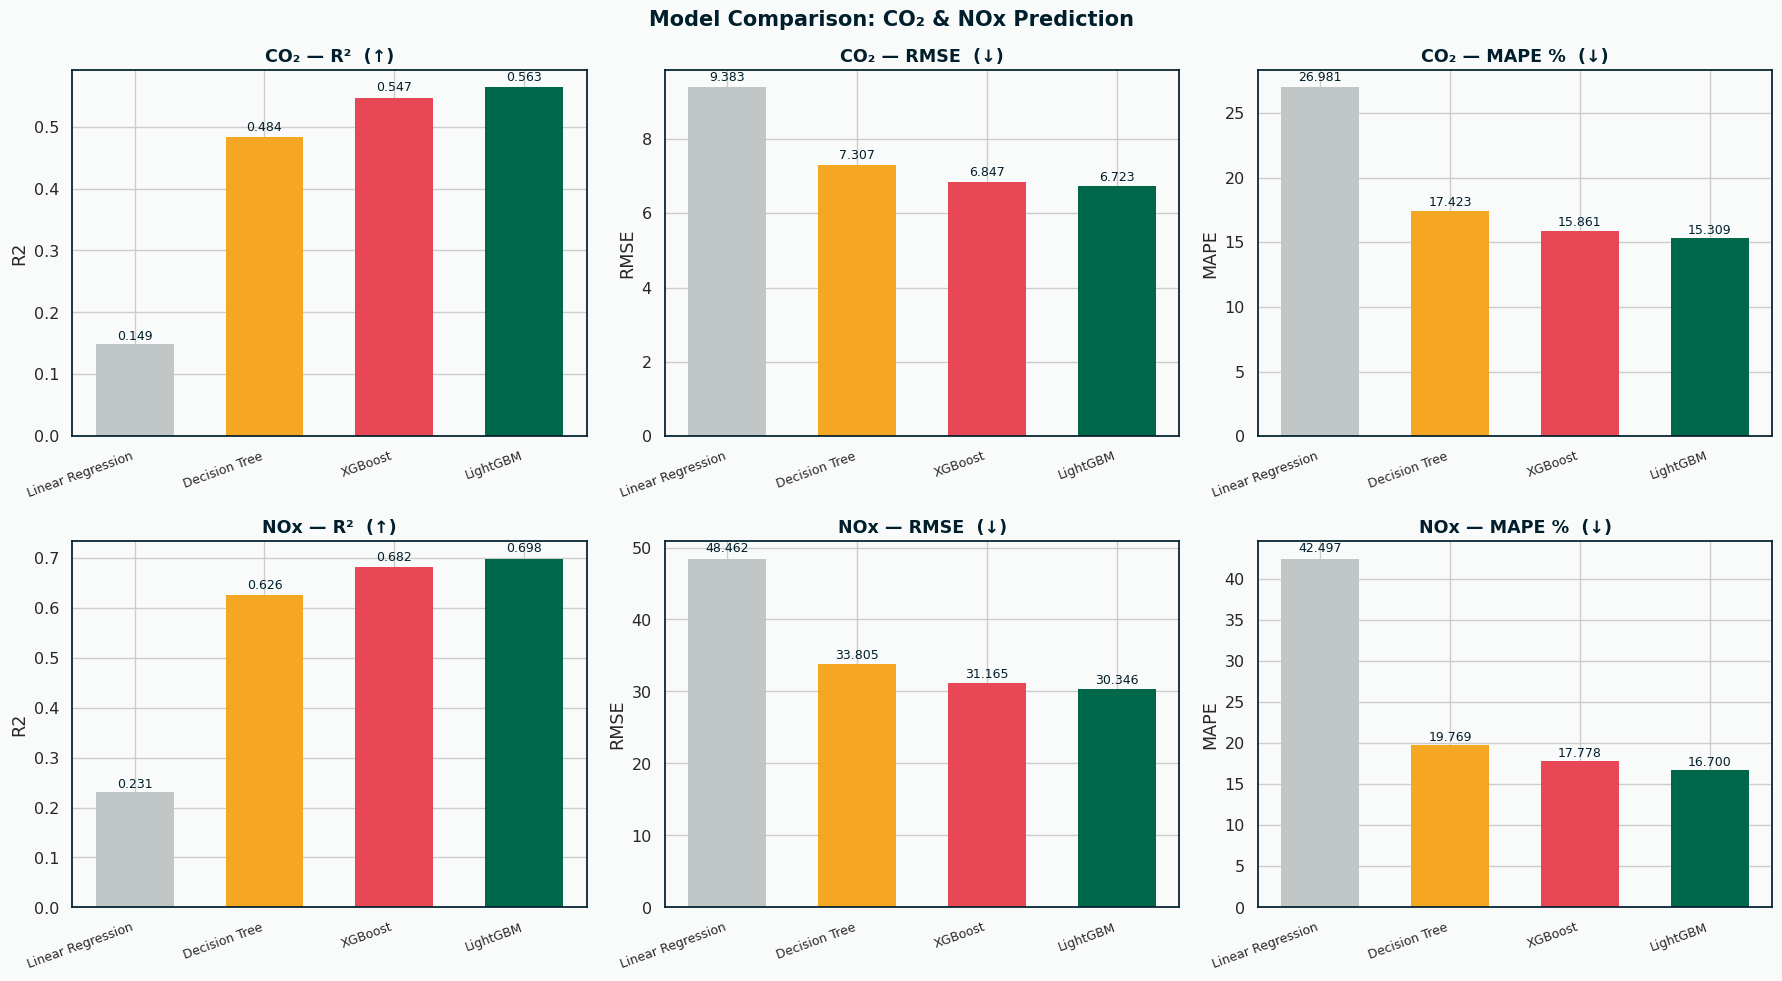

  -> modeling_01_comparison.png


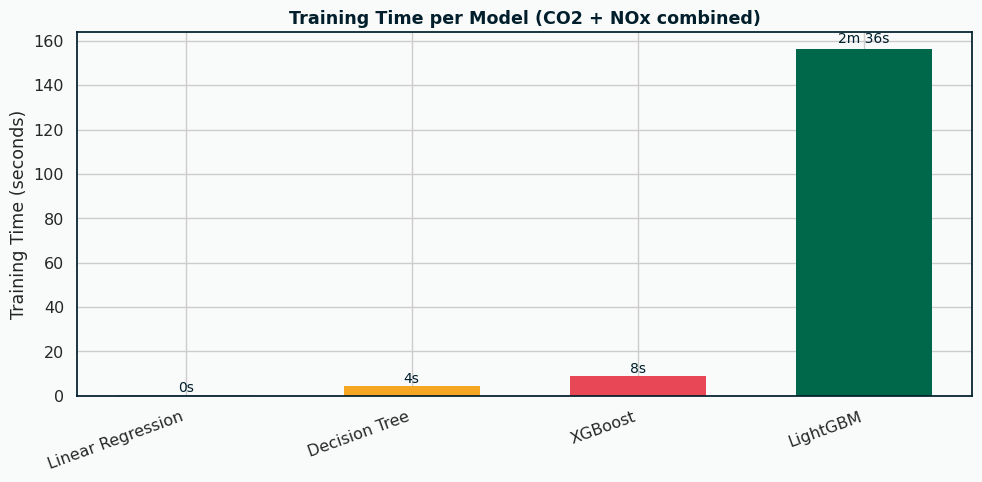

  -> modeling_02_train_time.png

[08:24:13] Best CO2: LightGBM (R²=0.5631)
[08:24:13] Best NOx: LightGBM (R²=0.6983)


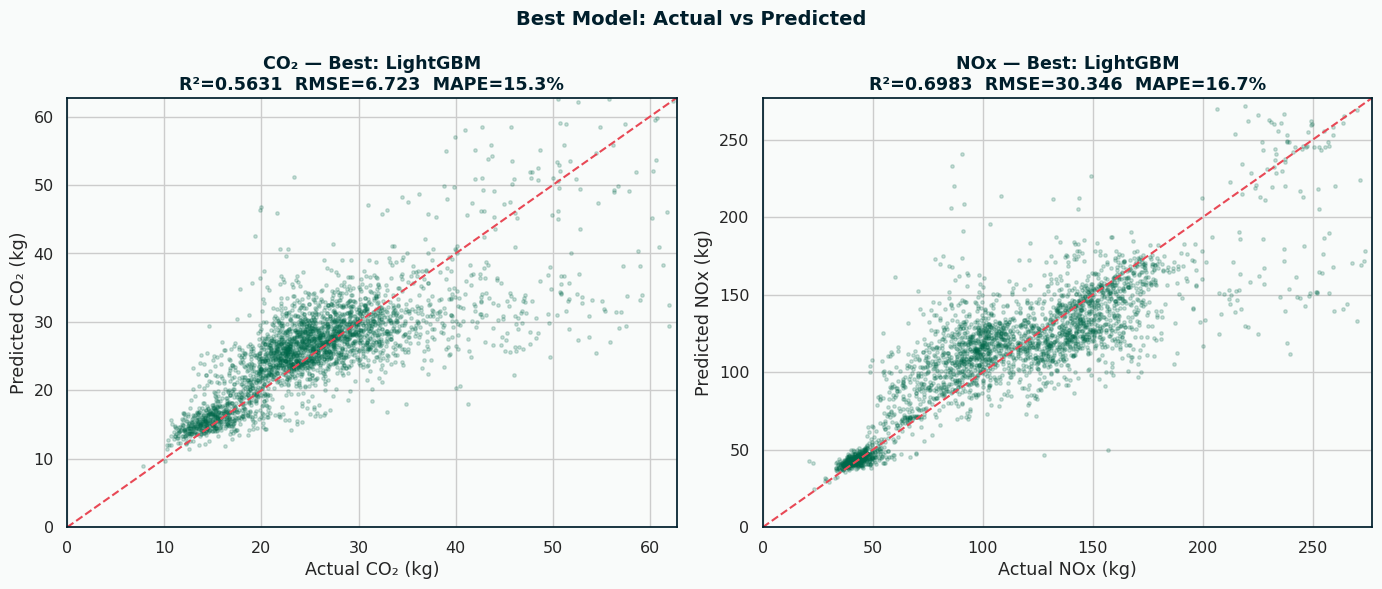

  -> modeling_03_actual_vs_pred.png
[08:24:14] SHAP: CO₂ (LightGBM)...


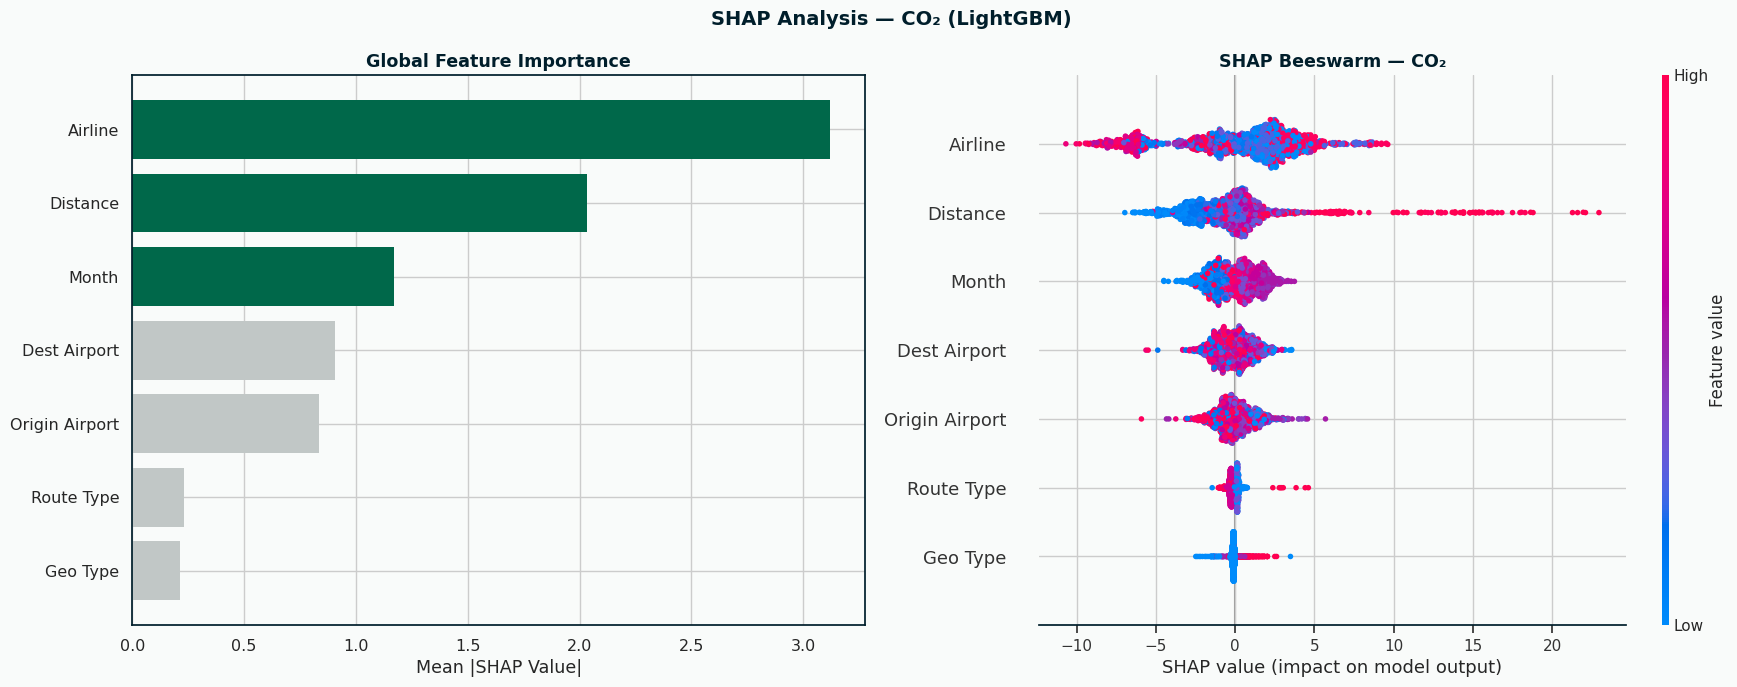

  -> modeling_04_shap_co2.png
[08:24:38] SHAP: NOx (LightGBM)...


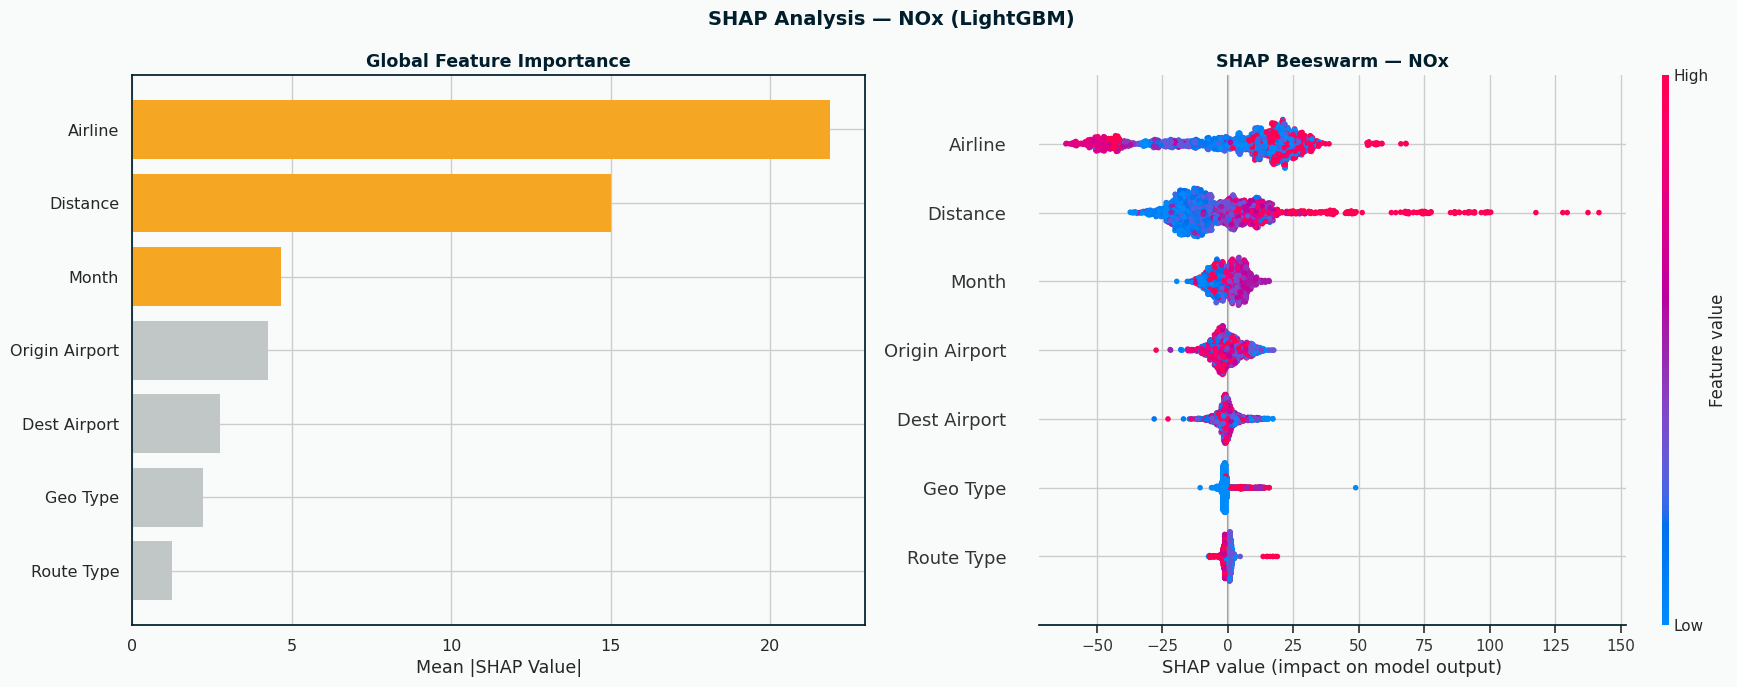

  -> modeling_04_shap_nox.png

  FINAL SUMMARY
Model                  CO2 R²   CO2 RMSE   CO2 MAPE   NOx R²   NOx MAPE     Time
---------------------------------------------------------------------------
Linear Regression      0.1489       9.38     26.98%   0.2307     42.50%       0s
Decision Tree          0.4838       7.31     17.42%   0.6256     19.77%       4s
XGBoost                0.5468       6.85     15.86%   0.6818     17.78%       8s
LightGBM               0.5631       6.72     15.31%   0.6983     16.70%    2m36s

Best CO2: LightGBM (R²=0.5631)
Best NOx: LightGBM (R²=0.6983)
Total elapsed: 3m 41s


In [ ]:
"""
Modeling: Multi-Model Comparison
CIVENG 160D Final Project

Models:
  - Linear Regression
  - Decision Tree
  - Random Forest (50 trees)
  - MLP (Neural Network, GPU)
  - XGBoost (GPU)
  - LightGBM (GPU)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from xgboost import XGBRegressor
import lightgbm as lgb
import shap
import time, copy
from datetime import datetime, timedelta

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ─── Style ────────────────────────────────────────────────────────────────────
PALETTE = {
    "primary":   "#00684A",
    "secondary": "#001E2B",
    "accent":    "#00A35C",
    "warning":   "#F5A623",
    "danger":    "#E84855",
    "muted":     "#C1C7C6",
    "bg":        "#F9FBFA",
}
OUTPUT_DIR = "./"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.edgecolor":   PALETTE["secondary"], "text.color": PALETTE["secondary"],
    "font.family":      "DejaVu Sans",
})

EXPECTED_TIMES = {
    "Linear Regression": 10,
    "Decision Tree":     30,
    # "Random Forest":     420,   # ~7min (50 trees)
    # "MLP":               300,   # ~5min (GPU)
    "XGBoost":           300,
    "LightGBM":          120,
}


# ─── Progress ─────────────────────────────────────────────────────────────────
def print_progress(name, phase, elapsed=None, expected=None):
    now = datetime.now().strftime("%H:%M:%S")
    if phase == "start":
        exp_str = f"{expected//60}m {expected%60}s" if expected >= 60 else f"{expected}s"
        print(f"\n[{now}] Starting {name}  (estimated: ~{exp_str})")
    elif phase == "done":
        mins, secs = divmod(int(elapsed), 60)
        t = f"{mins}m {secs}s" if mins > 0 else f"{secs}s"
        print(f"[{now}] Done: {name}  (actual: {t})")


# ═══════════════════════════════════════════════════════════════════════════════
# 1. Data Preparation
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("  CIVENG 160D — LTO Emissions Multi-Model Comparison")
print("=" * 60)
print(f"\n[{datetime.now().strftime('%H:%M:%S')}] Loading data...")

df = pd.read_parquet("/content/40_2025_final.parquet")

CO2_COLS = ["Taxi Out CO2", "Take Off CO2", "Climb Out CO2", "Approach CO2", "Taxi In CO2"]
NOX_COLS = ["Taxi Out NOx", "Take Off NOx", "Climb Out NOx", "Approach NOx", "Taxi In NOx"]

df["Total_CO2"]  = df[CO2_COLS].sum(axis=1)
df["Total_NOx"]  = df[NOX_COLS].sum(axis=1)
df["Total_Taxi"] = df["TAXI_OUT"].fillna(0) + df["TAXI_IN"].fillna(0)

cat_cols = ["ORIGIN", "DEST", "OP_CARRIER", "ACFT MODEL",
            "ACFT MFR CLEAN", "ENG MODEL", "ROUTE_TYPE", "GEO_TYPE"]
for col in cat_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))

# Pre-flight only features (no taxi time, air time, or engine model)
FEATURE_COLS = [
    # Route
    "DISTANCE",
    "ORIGIN_enc", "DEST_enc",
    "ROUTE_TYPE_enc", "GEO_TYPE_enc",
    # Schedule
    "MONTH",
    # Airline & Fleet (known at scheduling stage)
    "OP_CARRIER_enc"
]

FEAT_LABELS = {
    "DISTANCE":          "Distance",
    "ORIGIN_enc":        "Origin Airport",
    "DEST_enc":          "Dest Airport",
    "ROUTE_TYPE_enc":    "Route Type",
    "GEO_TYPE_enc":      "Geo Type",
    "MONTH":             "Month",
    "OP_CARRIER_enc":    "Airline",
}

model_df = df[FEATURE_COLS + ["Total_CO2", "Total_NOx"]].dropna()
print(f"[{datetime.now().strftime('%H:%M:%S')}] Loaded: {len(model_df):,} rows x {len(FEATURE_COLS)} features")

X = model_df[FEATURE_COLS]
y_co2 = model_df["Total_CO2"]
y_nox = model_df["Total_NOx"]

X_train, X_test, y_co2_train, y_co2_test, y_nox_train, y_nox_test = train_test_split(
    X, y_co2, y_nox, test_size=0.2, random_state=42
)
print(f"[{datetime.now().strftime('%H:%M:%S')}] Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# Scaled version for MLP
scaler_X   = StandardScaler()
scaler_co2 = StandardScaler()
scaler_nox = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_co2_train_sc = scaler_co2.fit_transform(y_co2_train.values.reshape(-1,1)).ravel()
y_nox_train_sc = scaler_nox.fit_transform(y_nox_train.values.reshape(-1,1)).ravel()


# ═══════════════════════════════════════════════════════════════════════════════
# 2. MLP Definition
# ═══════════════════════════════════════════════════════════════════════════════
'''
class MLPNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


class MLPRegressor(BaseEstimator, RegressorMixin):
    """sklearn-compatible MLP wrapper using PyTorch + GPU"""
    def __init__(self, input_dim, epochs=50, batch_size=2048, lr=1e-3, patience=5):
        self.input_dim  = input_dim
        self.epochs     = epochs
        self.batch_size = batch_size
        self.lr         = lr
        self.patience   = patience

    def fit(self, X, y):
        X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        y_t = torch.tensor(y, dtype=torch.float32).to(DEVICE)

        ds     = TensorDataset(X_t, y_t)
        loader = DataLoader(ds, batch_size=self.batch_size, shuffle=True)

        self.model_ = MLPNet(self.input_dim).to(DEVICE)
        optimizer   = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)
        criterion   = nn.MSELoss()

        best_loss, no_improve = float("inf"), 0
        for epoch in range(1, self.epochs + 1):
            self.model_.train()
            epoch_loss = 0
            for xb, yb in loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(xb), yb)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(xb)
            epoch_loss /= len(ds)
            scheduler.step(epoch_loss)

            if epoch % 10 == 0:
                print(f"    Epoch {epoch:3d}/{self.epochs}  loss={epoch_loss:.6f}")

            if epoch_loss < best_loss - 1e-6:
                best_loss  = epoch_loss
                no_improve = 0
                self.best_state_ = {k: v.clone() for k, v in self.model_.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= self.patience:
                    print(f"    Early stopping at epoch {epoch}")
                    break

        self.model_.load_state_dict(self.best_state_)
        return self

    def predict(self, X):
        self.model_.eval()
        X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            return self.model_(X_t).cpu().numpy()

'''
# ═══════════════════════════════════════════════════════════════════════════════
# 3. Model Definitions
# ═══════════════════════════════════════════════════════════════════════════════
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree":     DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42),
    #"Random Forest":     RandomForestRegressor(n_estimators=50, max_depth=10,
                                               #min_samples_leaf=10, n_jobs=-1,
                                               #random_state=42, verbose=1),
    #"MLP":               MLPRegressor(input_dim=len(FEATURE_COLS),  # auto-updated
                                      #epochs=50, batch_size=2048, lr=1e-3, patience=5),
    "XGBoost":           XGBRegressor(n_estimators=500, learning_rate=0.05,
                                      max_depth=6, subsample=0.8,
                                      colsample_bytree=0.8, random_state=42,
                                      verbosity=1, device="cuda", n_jobs=-1),
    "LightGBM":          lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05,
                                            num_leaves=63, subsample=0.8,
                                            colsample_bytree=0.8, random_state=42,
                                            verbose=-1, device="gpu", n_jobs=-1),
}

MODEL_COLORS = {
    "Linear Regression": PALETTE["muted"],
    "Decision Tree":     PALETTE["warning"],
    #"Random Forest":     PALETTE["accent"],
    #"MLP":               "#9B59B6",
    "XGBoost":           PALETTE["danger"],
    "LightGBM":          PALETTE["primary"],
}

total_models   = len(models)
total_expected = sum(EXPECTED_TIMES.values()) * 2
exp_mins, exp_secs = divmod(total_expected, 60)
print(f"\n[{datetime.now().strftime('%H:%M:%S')}] {total_models} models x CO2/NOx")
print(f"[{datetime.now().strftime('%H:%M:%S')}] Total estimated: ~{exp_mins}m {exp_secs}s")
print(f"[{datetime.now().strftime('%H:%M:%S')}] GPU: {DEVICE}")


# ═══════════════════════════════════════════════════════════════════════════════
# 4. Train & Evaluate
# ═══════════════════════════════════════════════════════════════════════════════
def train_and_eval(name, model, X_tr, y_tr, X_te, y_te, scaler_y=None):
    if name == "LightGBM":
        model.fit(X_tr, y_tr,
                  eval_set=[(X_te, y_te)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(100)])
    elif name == "XGBoost":
        model.fit(X_tr, y_tr,
                  eval_set=[(X_te, y_te)],
                  verbose=50)
    else:
        model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)

    # MLP: inverse scale
    #if scaler_y is not None:
        #y_pred = scaler_y.inverse_transform(y_pred.reshape(-1,1)).ravel()

    return {
        "R2":   r2_score(y_te, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_te, y_pred) * 100,
        "pred": y_pred,
    }

results_co2, results_nox = {}, {}
fitted_co2,  fitted_nox  = {}, {}
actual_times = {}
global_start = time.time()
done_count   = 0

print(f"\n{'─'*60}")
for name in models:
    exp = EXPECTED_TIMES[name]
    print_progress(name, "start", expected=exp)
    t0 = time.time()

    m_co2 = copy.deepcopy(models[name])
    m_nox = copy.deepcopy(models[name])

    # MLP uses scaled data

    if name == "MLP":
        r_co2 = train_and_eval(name, m_co2, X_train_sc, y_co2_train_sc,
                                X_test_sc, y_co2_test, scaler_y=scaler_co2)
        co2_t = time.time() - t0
        print(f"[{datetime.now().strftime('%H:%M:%S')}]    CO2 done ({co2_t:.0f}s) → NOx training...")
        t1 = time.time()
        r_nox = train_and_eval(name, m_nox, X_train_sc, y_nox_train_sc,
                                X_test_sc, y_nox_test, scaler_y=scaler_nox)

    else:
        r_co2 = train_and_eval(name, m_co2, X_train, y_co2_train, X_test, y_co2_test)
        co2_t = time.time() - t0
        print(f"[{datetime.now().strftime('%H:%M:%S')}]    CO2 done ({co2_t:.0f}s) → NOx training...")
        t1 = time.time()
        r_nox = train_and_eval(name, m_nox, X_train, y_nox_train, X_test, y_nox_test)

    total_t = time.time() - t0
    actual_times[name] = total_t
    results_co2[name]  = r_co2
    results_nox[name]  = r_nox
    fitted_co2[name]   = m_co2
    fitted_nox[name]   = m_nox

    done_count += 1
    print_progress(name, "done", elapsed=total_t)
    print(f"         CO2 → R²={r_co2['R2']:.4f}  RMSE={r_co2['RMSE']:.2f}  MAPE={r_co2['MAPE']:.1f}%")
    print(f"         NOx → R²={r_nox['R2']:.4f}  RMSE={r_nox['RMSE']:.4f}  MAPE={r_nox['MAPE']:.1f}%")

    if done_count < total_models:
        remaining = list(models.keys())[done_count:]
        rem_exp   = sum(EXPECTED_TIMES[n] * 2 for n in remaining)
        eta_dt    = datetime.now() + timedelta(seconds=rem_exp)
        elapsed   = time.time() - global_start
        print(f"         Remaining: {len(remaining)} models  |  ETA: {eta_dt.strftime('%H:%M')}  "
              f"|  Elapsed: {int(elapsed//60)}m {int(elapsed%60)}s")


# ═══════════════════════════════════════════════════════════════════════════════
# 5. Comparison Plots
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n[{datetime.now().strftime('%H:%M:%S')}] Generating plots...")

model_names   = list(models.keys())
metrics       = ["R2", "RMSE", "MAPE"]
metric_labels = {"R2": "R²  (↑)", "RMSE": "RMSE  (↓)", "MAPE": "MAPE %  (↓)"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Comparison: CO₂ & NOx Prediction",
             fontsize=15, fontweight="bold", color=PALETTE["secondary"])

for row, (results, target) in enumerate([(results_co2, "CO₂"), (results_nox, "NOx")]):
    for col, metric in enumerate(metrics):
        ax    = axes[row, col]
        vals  = [results[m][metric] for m in model_names]
        cols  = [MODEL_COLORS[m] for m in model_names]
        bars  = ax.bar(model_names, vals, color=cols, edgecolor="none", width=0.6)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)
        ax.set_title(f"{target} — {metric_labels[metric]}", fontweight="bold")
        ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
        ax.set_ylabel(metric)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}modeling_01_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  -> modeling_01_comparison.png")

# Training time chart
fig, ax = plt.subplots(figsize=(10, 5))
times  = [actual_times[n] for n in model_names]
colors = [MODEL_COLORS[n] for n in model_names]
bars   = ax.bar(model_names, times, color=colors, edgecolor="none", width=0.6)
for bar, t in zip(bars, times):
    mins, secs = divmod(int(t), 60)
    label = f"{mins}m {secs}s" if mins > 0 else f"{secs}s"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            label, ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Training Time (seconds)")
ax.set_title("Training Time per Model (CO2 + NOx combined)", fontweight="bold")
ax.set_xticklabels(model_names, rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}modeling_02_train_time.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  -> modeling_02_train_time.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 6. Actual vs Predicted
# ═══════════════════════════════════════════════════════════════════════════════
best_co2 = max(results_co2, key=lambda m: results_co2[m]["R2"])
best_nox = max(results_nox, key=lambda m: results_nox[m]["R2"])
print(f"\n[{datetime.now().strftime('%H:%M:%S')}] Best CO2: {best_co2} (R²={results_co2[best_co2]['R2']:.4f})")
print(f"[{datetime.now().strftime('%H:%M:%S')}] Best NOx: {best_nox} (R²={results_nox[best_nox]['R2']:.4f})")

sample_idx = np.random.choice(len(y_co2_test), min(3000, len(y_co2_test)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Best Model: Actual vs Predicted",
             fontsize=14, fontweight="bold", color=PALETTE["secondary"])

for ax, (results, y_test, best, target) in zip(axes, [
    (results_co2, y_co2_test, best_co2, "CO₂"),
    (results_nox, y_nox_test, best_nox, "NOx"),
]):
    pred = results[best]["pred"]
    ax.scatter(y_test.iloc[sample_idx], pred[sample_idx],
               alpha=0.2, s=6, color=MODEL_COLORS[best])
    lim = [0, np.percentile(y_test, 99)]
    ax.plot(lim, lim, color=PALETTE["danger"], linewidth=1.5, linestyle="--")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"Actual {target} (kg)")
    ax.set_ylabel(f"Predicted {target} (kg)")
    ax.set_title(
        f"{target} — Best: {best}\n"
        f"R²={results[best]['R2']:.4f}  RMSE={results[best]['RMSE']:.3f}  MAPE={results[best]['MAPE']:.1f}%",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}modeling_03_actual_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  -> modeling_03_actual_vs_pred.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 7. SHAP — Tree-based Best Model
# ═══════════════════════════════════════════════════════════════════════════════
TREE_MODELS = ["LightGBM", "XGBoost", "Decision Tree"]

best_co2_shap = max((m for m in results_co2 if m in TREE_MODELS),
                     key=lambda m: results_co2[m]["R2"])
best_nox_shap = max((m for m in results_nox if m in TREE_MODELS),
                     key=lambda m: results_nox[m]["R2"])

X_shap = X_test.sample(min(2000, len(X_test)), random_state=42)
X_shap_labeled = X_shap.rename(columns=FEAT_LABELS)

for target, best, fitted, color, tag in [
    ("CO₂", best_co2_shap, fitted_co2, PALETTE["primary"], "co2"),
    ("NOx", best_nox_shap, fitted_nox, PALETTE["warning"], "nox"),
]:
    print(f"[{datetime.now().strftime('%H:%M:%S')}] SHAP: {target} ({best})...")
    explainer = shap.TreeExplainer(fitted[best])
    shap_vals = explainer.shap_values(X_shap)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"SHAP Analysis — {target} ({best})",
                 fontsize=14, fontweight="bold", color=PALETTE["secondary"])

    shap_mean = np.abs(shap_vals).mean(axis=0)
    shap_df   = pd.DataFrame({
        "feature":    list(FEAT_LABELS.values()),
        "importance": shap_mean
    }).sort_values("importance", ascending=True)

    bar_colors = [color if v > shap_df["importance"].median()
                  else PALETTE["muted"] for v in shap_df["importance"]]
    axes[0].barh(shap_df["feature"], shap_df["importance"],
                 color=bar_colors, edgecolor="none")
    axes[0].set_xlabel("Mean |SHAP Value|")
    axes[0].set_title("Global Feature Importance", fontweight="bold")

    shap.summary_plot(shap_vals, X_shap_labeled,
                      plot_type="dot", show=False, plot_size=None, max_display=17)
    plt.gca().set_title(f"SHAP Beeswarm — {target}", fontweight="bold")

    plt.tight_layout()
    fname = f"modeling_04_shap_{tag}.png"
    plt.savefig(f"{OUTPUT_DIR}{fname}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  -> {fname}")


# ─── Final Summary ─────────────────────────────────────────────────────────────
total_elapsed = time.time() - global_start
total_mins, total_secs = divmod(int(total_elapsed), 60)

print()
print("=" * 75)
print("  FINAL SUMMARY")
print("=" * 75)
print(f"{'Model':<20} {'CO2 R²':>8} {'CO2 RMSE':>10} {'CO2 MAPE':>10} "
      f"{'NOx R²':>8} {'NOx MAPE':>10} {'Time':>8}")
print("-" * 75)
for name in model_names:
    mins, secs = divmod(int(actual_times[name]), 60)
    t_str = f"{mins}m{secs}s" if mins > 0 else f"{secs}s"
    print(f"{name:<20} {results_co2[name]['R2']:>8.4f}"
          f" {results_co2[name]['RMSE']:>10.2f}"
          f" {results_co2[name]['MAPE']:>9.2f}%"
          f" {results_nox[name]['R2']:>8.4f}"
          f" {results_nox[name]['MAPE']:>9.2f}%"
          f" {t_str:>8}")
print()
print(f"Best CO2: {best_co2} (R²={results_co2[best_co2]['R2']:.4f})")
print(f"Best NOx: {best_nox} (R²={results_nox[best_nox]['R2']:.4f})")
print(f"Total elapsed: {total_mins}m {total_secs}s")

In [ ]:
print('OP_CARRIER' in model_df.columns)

False


In [ ]:
from sklearn.metrics import r2_score

# model_df 만들 때 OP_CARRIER 포함시키기
model_df2 = df[FEATURE_COLS + ["Total_CO2", "Total_NOx", "OP_CARRIER"]].dropna()

test_df = model_df2.loc[X_test.index].copy()
test_df['y_true_co2'] = y_co2_test.values
test_df['y_pred_co2'] = fitted_co2['LightGBM'].predict(X_test)
test_df['y_true_nox'] = y_nox_test.values
test_df['y_pred_nox'] = fitted_nox['LightGBM'].predict(X_test)

print(f"{'Carrier':<8} {'CO2 R²':>8} {'NOx R²':>8} {'n':>6}")
print("-" * 35)
for carrier in sorted(test_df['OP_CARRIER'].unique()):
    sub = test_df[test_df['OP_CARRIER'] == carrier]
    if len(sub) < 30:
        continue
    r2_co2 = r2_score(sub['y_true_co2'], sub['y_pred_co2'])
    r2_nox = r2_score(sub['y_true_nox'], sub['y_pred_nox'])
    print(f"{carrier:<8} {r2_co2:>8.4f} {r2_nox:>8.4f} {len(sub):>6}")

Carrier    CO2 R²   NOx R²      n
-----------------------------------
9E         0.2315   0.2627   2821
AA         0.2509   0.4681  62349
AS         0.2005   0.1489  21755
B6         0.4110   0.6134  15466
C5        -1.3676 -17.3788     37
DL         0.5816   0.6945  50483
F9         0.1377   0.1590  12790
G4         0.1910   0.2436    248
G7         0.0893   0.1391   1978
HA         0.7449   0.8005   6237
MQ         0.1675   0.2130   3990
NK         0.1868   0.3009   5941
OH         0.1117   0.0519   4867
OO         0.2460   0.3569  16906
PT         0.2724   0.3529    625
QX         0.2606   0.3229   3148
UA         0.3808   0.4574  56400
WN         0.3304   0.2525  25441
YV         0.1891   0.2504   1069
YX         0.1355   0.2124  13915


In [ ]:
from sklearn.metrics import r2_score

# OP_CARRIER는 model_df에서 가져와야 해
test_df = X_test.copy()
test_df['OP_CARRIER'] = model_df.loc[X_test.index, 'OP_CARRIER']
test_df['y_true_co2'] = y_co2_test.values
test_df['y_pred_co2'] = fitted_co2['LightGBM'].predict(X_test)
test_df['y_true_nox'] = y_nox_test.values
test_df['y_pred_nox'] = fitted_nox['LightGBM'].predict(X_test)

print(f"{'Carrier':<8} {'CO2 R²':>8} {'NOx R²':>8} {'n':>6}")
print("-" * 35)
for carrier in sorted(test_df['OP_CARRIER'].unique()):
    sub = test_df[test_df['OP_CARRIER'] == carrier]
    if len(sub) < 30:
        continue
    r2_co2 = r2_score(sub['y_true_co2'], sub['y_pred_co2'])
    r2_nox = r2_score(sub['y_true_nox'], sub['y_pred_nox'])
    print(f"{carrier:<8} {r2_co2:>8.4f} {r2_nox:>8.4f} {len(sub):>6}")

KeyError: 'OP_CARRIER'

In [ ]:
from sklearn.metrics import r2_score

# 테스트셋에 항공사 정보 붙이기
test_df = X_test.copy()
test_df['OP_CARRIER'] = model_df.loc[X_test.index, 'OP_CARRIER']
test_df['y_true_co2'] = y_co2_test
test_df['y_pred_co2'] = fitted_co2['LightGBM'].predict(X_test)
test_df['y_true_nox'] = y_nox_test
test_df['y_pred_nox'] = fitted_nox['LightGBM'].predict(X_test)

# 항공사별 R²
print("Airline-level R² (LightGBM)")
print(f"{'Carrier':<8} {'CO2 R²':>8} {'NOx R²':>8} {'n':>6}")
print("-" * 35)
for carrier in sorted(test_df['OP_CARRIER'].unique()):
    sub = test_df[test_df['OP_CARRIER'] == carrier]
    if len(sub) < 30:
        continue
    r2_co2 = r2_score(sub['y_true_co2'], sub['y_pred_co2'])
    r2_nox = r2_score(sub['y_true_nox'], sub['y_pred_nox'])
    print(f"{carrier:<8} {r2_co2:>8.4f} {r2_nox:>8.4f} {len(sub):>6}")

KeyError: 'OP_CARRIER'

In [ ]:
CO2_COLS = ["Taxi Out CO2", "Take Off CO2", "Climb Out CO2", "Approach CO2", "Taxi In CO2"]
df["Total_CO2"]  = df[CO2_COLS].sum(axis=1)
df["CO2_per_km"] = df["Total_CO2"] / df["DISTANCE"].replace(0, np.nan)

In [ ]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 항공사별 CO2/km 차이가 유의한가?
groups = [df[df['OP_CARRIER'] == c]['CO2_per_km'].dropna()
          for c in df['OP_CARRIER'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F={f_stat:.2f}, p={p_val:.4f}")

F=11295.37, p=0.0000


In [ ]:
from scipy import stats

# 최소 100편 이상 항공사만
carrier_counts = df['OP_CARRIER'].value_counts()
valid_carriers = carrier_counts[carrier_counts >= 100].index.tolist()

groups = [df[df['OP_CARRIER'] == c]['CO2_per_km'].dropna().values
          for c in valid_carriers]

f_stat, p_val = stats.f_oneway(*groups)

# Eta-squared (효과 크기)
grand_mean = df['CO2_per_km'].dropna().mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total   = sum(((g - grand_mean)**2).sum() for g in groups)
eta_sq     = ss_between / ss_total

print(f"Valid carriers: {len(valid_carriers)}")
print(f"F = {f_stat:.2f},  p = {p_val:.2e}")
print(f"Eta² = {eta_sq:.4f}  ({eta_sq*100:.1f}% of variance explained by airline)")

Valid carriers: 20
F = 11884.79,  p = 0.00e+00
Eta² = 0.1284  (12.8% of variance explained by airline)


In [ ]:
# 최소 100편 이상 공항만
airport_counts = df['ORIGIN'].value_counts()
valid_airports = airport_counts[airport_counts >= 100].index.tolist()

groups_ap = [df[df['ORIGIN'] == a]['CO2_per_km'].dropna().values
             for a in valid_airports]

f_ap, p_ap = stats.f_oneway(*groups_ap)

# Eta-squared
grand_mean = df['CO2_per_km'].dropna().mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups_ap)
ss_total   = sum(((g - grand_mean)**2).sum() for g in groups_ap)
eta_sq_ap  = ss_between / ss_total

print(f"Valid airports: {len(valid_airports)}")
print(f"F = {f_ap:.2f},  p = {p_ap:.2e}")
print(f"Eta² = {eta_sq_ap:.4f}  ({eta_sq_ap*100:.1f}% of variance explained by airport)")

Valid airports: 40
F = 6447.07,  p = 0.00e+00
Eta² = 0.1410  (14.1% of variance explained by airport)


In [ ]:
# 온도 구간별 ANOVA
df["Temp_Bin"] = pd.cut(
    df["orig_temp_C"],
    bins=[-30, -10, 0, 10, 20, 30, 45],
    labels=["<-10°C", "-10–0°C", "0–10°C", "10–20°C", "20–30°C", ">30°C"]
)

temp_counts = df["Temp_Bin"].value_counts()
valid_temps = temp_counts[temp_counts >= 100].index.tolist()

groups_temp = [df[df["Temp_Bin"] == t]["CO2_per_km"].dropna().values
               for t in valid_temps]

f_temp, p_temp = stats.f_oneway(*groups_temp)

# Eta-squared
grand_mean = df["CO2_per_km"].dropna().mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups_temp)
ss_total   = sum(((g - grand_mean)**2).sum() for g in groups_temp)
eta_sq_temp = ss_between / ss_total

print(f"Valid temp bins: {len(valid_temps)}")
print(f"F = {f_temp:.2f},  p = {p_temp:.2e}")
print(f"Eta² = {eta_sq_temp:.4f}  ({eta_sq_temp*100:.2f}% of variance explained by temperature)")

# 구간별 평균 출력
print("\nCO2_per_km by temp bin:")
print(df.groupby("Temp_Bin", observed=True)["CO2_per_km"].agg(["mean","count"]).round(4))

Valid temp bins: 6
F = 3868.99,  p = 0.00e+00
Eta² = 0.0125  (1.25% of variance explained by temperature)

CO2_per_km by temp bin:
            mean   count
Temp_Bin                
<-10°C    0.0293   10142
-10–0°C   0.0348   92696
0–10°C    0.0345  281561
10–20°C   0.0355  535107
20–30°C   0.0431  515236
>30°C     0.0385   97352


In [ ]:
# 기압 구간별 ANOVA
df["Pressure_Bin"] = pd.cut(
    df["orig_pressure_hPa"],
    bins=[800, 850, 900, 950, 970, 990, 1050],
    labels=["800–850", "850–900", "900–950", "950–970", "970–990", "990–1050"]
)

pressure_counts = df["Pressure_Bin"].value_counts()
valid_pressures = pressure_counts[pressure_counts >= 100].index.tolist()

groups_pres = [df[df["Pressure_Bin"] == p]["CO2_per_km"].dropna().values
               for p in valid_pressures]

f_pres, p_pres = stats.f_oneway(*groups_pres)

# Eta-squared
grand_mean = df["CO2_per_km"].dropna().mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups_pres)
ss_total   = sum(((g - grand_mean)**2).sum() for g in groups_pres)
eta_sq_pres = ss_between / ss_total

print(f"Valid pressure bins: {len(valid_pressures)}")
print(f"F = {f_pres:.2f},  p = {p_pres:.2e}")
print(f"Eta² = {eta_sq_pres:.4f}  ({eta_sq_pres*100:.2f}% of variance explained by pressure)")

# 구간별 평균
print("\nCO2_per_km by pressure bin:")
print(df.groupby("Pressure_Bin", observed=True)["CO2_per_km"].agg(["mean","count"]).round(4))

Valid pressure bins: 6
F = 2885.99,  p = 0.00e+00
Eta² = 0.0093  (0.93% of variance explained by pressure)

CO2_per_km by pressure bin:
                mean    count
Pressure_Bin                 
800–850       0.0342   101841
850–900       0.0363    51421
900–950       0.0802     7850
950–970       0.0360    17974
970–990       0.0366   238536
990–1050      0.0384  1113071


In [ ]:
# 900~950 hPa 구간 공항 분포 확인
subset = df[df["Pressure_Bin"] == "900–950"]
print(subset["ORIGIN"].value_counts().head(10))
print(f"Avg CO2/km: {subset['CO2_per_km'].mean():.4f}")
print(f"Median CO2/km: {subset['CO2_per_km'].median():.4f}")

ORIGIN
AVL    7777
ICT      60
LNK      10
LWS       3
Name: count, dtype: int64
Avg CO2/km: 0.0802
Median CO2/km: 0.0364


In [ ]:
# AVL outlier 확인
avl = df[df["ORIGIN"] == "AVL"]["CO2_per_km"].dropna()
print(f"Mean:   {avl.mean():.4f}")
print(f"Median: {avl.median():.4f}")
print(f"99th%:  {avl.quantile(0.99):.4f}")
print(f"Max:    {avl.max():.4f}")
print(f"CO2/km > 0.5: {(avl > 0.5).sum()}편")

Mean:   0.0804
Median: 0.0364
99th%:  0.3583
Max:    0.6391
CO2/km > 0.5: 6편


In [ ]:
avl_outliers = df[(df["ORIGIN"] == "AVL") & (df["CO2_per_km"] > 0.5)]
print(avl_outliers[["FL_DATE", "DEST", "DISTANCE", "TAIL_NUM",
                     "ACFT MODEL", "Total_CO2", "CO2_per_km"]].to_string())

           FL_DATE DEST  DISTANCE TAIL_NUM            ACFT MODEL  Total_CO2  CO2_per_km
558442  2025-05-19  CLT      91.0   N8030F  A319-115              47.053169    0.517068
561064  2025-05-17  CLT      91.0   N723UW  A319-112              58.159633    0.639117
662595  2025-06-03  CLT      91.0   N812AW  A319-132              50.537202    0.555354
1000573 2025-08-12  CLT      91.0   N9022G  A319-115              45.846361    0.503806
1054815 2025-09-05  CLT      91.0   N659AW  A320-232              47.458579    0.521523
1208366 2025-10-15  CLT      91.0   N155NN  A321-231              46.257888    0.508328


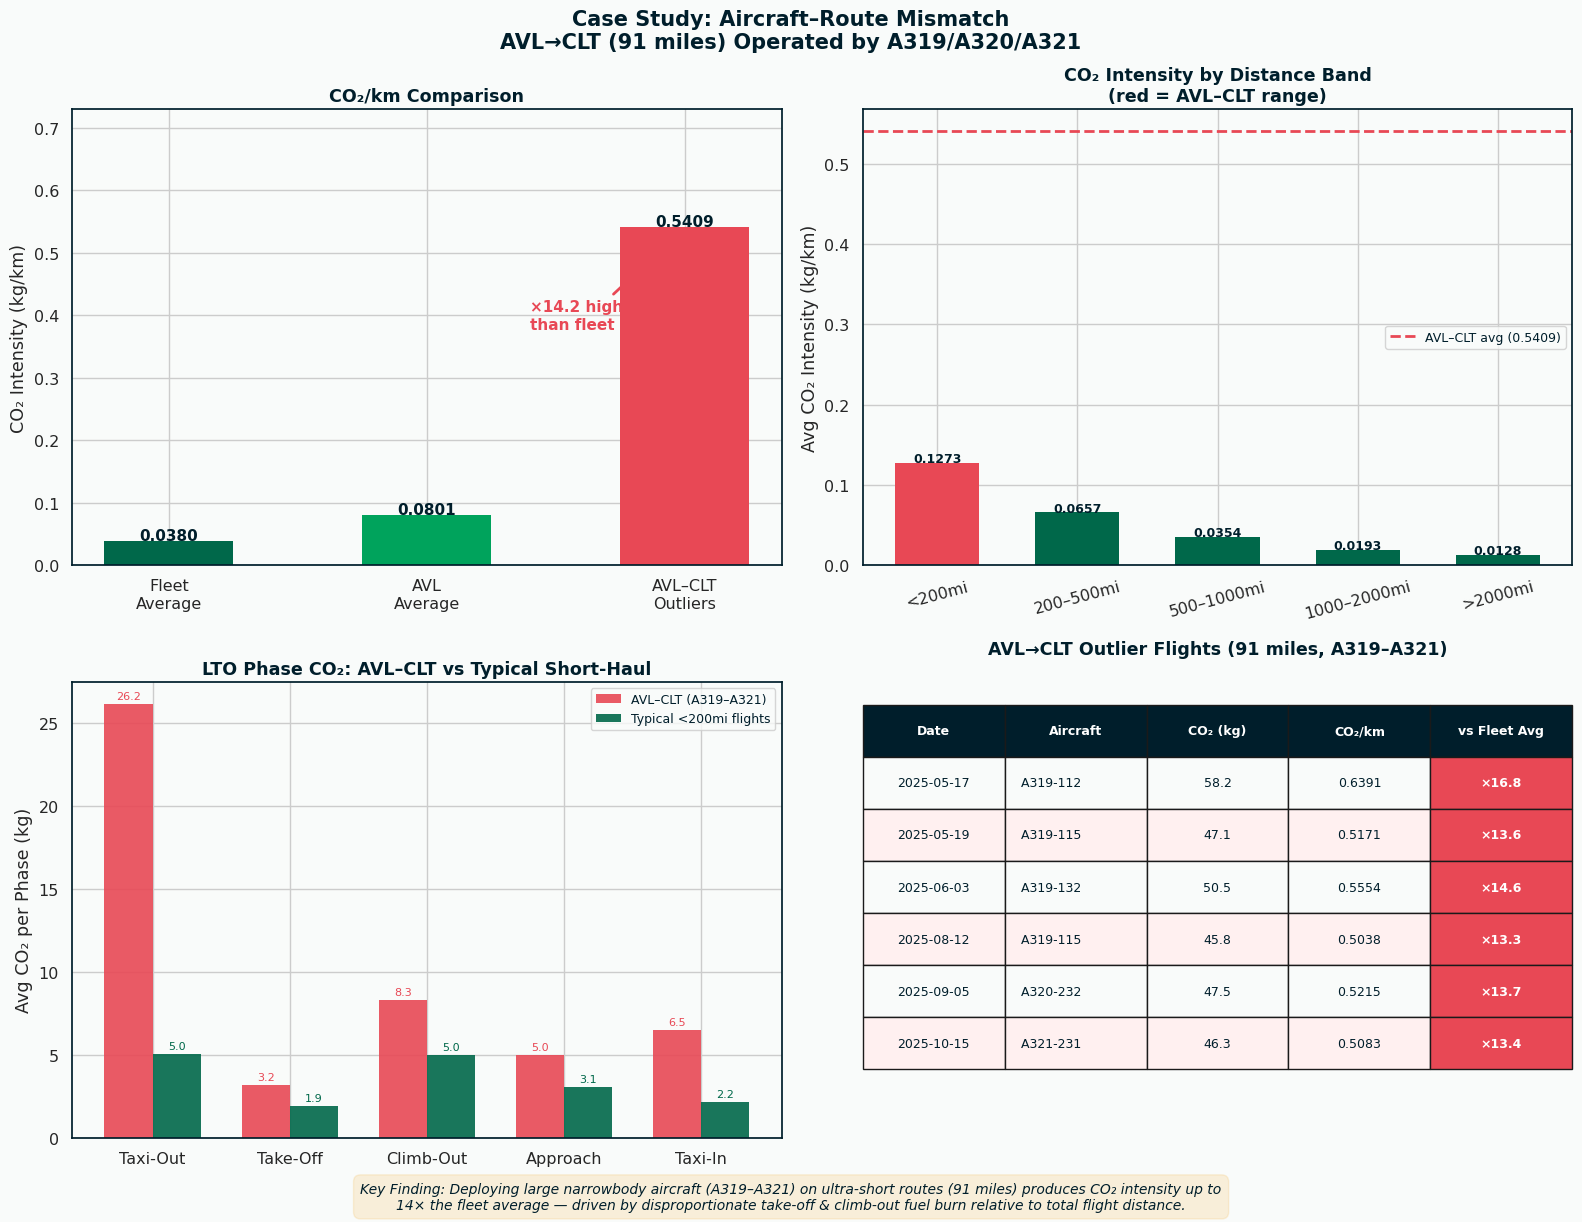

-> casestudy_avl_clt.png


In [ ]:
"""
AVL-CLT Route Inefficiency: Aircraft-Route Mismatch Case Study
CIVENG 160D Final Project
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

PALETTE = {
    "primary":   "#00684A",
    "secondary": "#001E2B",
    "accent":    "#00A35C",
    "warning":   "#F5A623",
    "danger":    "#E84855",
    "muted":     "#C1C7C6",
    "bg":        "#F9FBFA",
}
OUTPUT_DIR = "./"

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.edgecolor":   PALETTE["secondary"], "text.color": PALETTE["secondary"],
    "font.family":      "DejaVu Sans",
})

# ─── Data ─────────────────────────────────────────────────────────────────────
df = pd.read_parquet("/content/40_2025_final.parquet")

CO2_COLS = ["Taxi Out CO2", "Take Off CO2", "Climb Out CO2", "Approach CO2", "Taxi In CO2"]
df["Total_CO2"]  = df[CO2_COLS].sum(axis=1)
df["CO2_per_km"] = df["Total_CO2"] / df["DISTANCE"].replace(0, np.nan)

# AVL-CLT outliers
avl_clt = df[(df["ORIGIN"] == "AVL") & (df["DEST"] == "CLT") &
             (df["CO2_per_km"] > 0.5)].copy()

# Comparison groups
avl_normal  = df[(df["ORIGIN"] == "AVL") & ~((df["DEST"] == "CLT") &
                  (df["CO2_per_km"] > 0.5))]["CO2_per_km"].dropna()
all_flights = df["CO2_per_km"].dropna()

# Distance bins for context
df["Dist_Bin"] = pd.cut(df["DISTANCE"],
                         bins=[0, 200, 500, 1000, 2000, 6000],
                         labels=["<200mi", "200–500mi", "500–1000mi",
                                 "1000–2000mi", ">2000mi"])


# ═══════════════════════════════════════════════════════════════════════════════
# Figure: 4-panel case study
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Case Study: Aircraft–Route Mismatch\nAVL→CLT (91 miles) Operated by A319/A320/A321",
    fontsize=15, fontweight="bold", color=PALETTE["secondary"]
)

# ── 1. CO2/km comparison: outliers vs normal vs fleet average ──
ax = axes[0, 0]
categories = ["Fleet\nAverage", "AVL\nAverage", "AVL–CLT\nOutliers"]
means = [all_flights.mean(), avl_normal.mean(), avl_clt["CO2_per_km"].mean()]
colors = [PALETTE["primary"], PALETTE["accent"], PALETTE["danger"]]
bars = ax.bar(categories, means, color=colors, edgecolor="none", width=0.5)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")

# Multiplier annotation
multiplier = means[2] / means[0]
ax.annotate(
    f"×{multiplier:.1f} higher\nthan fleet avg",
    xy=(2, means[2]), xytext=(1.4, means[2] * 0.7),
    arrowprops=dict(arrowstyle="->", color=PALETTE["danger"], lw=2),
    fontsize=11, color=PALETTE["danger"], fontweight="bold"
)
ax.set_ylabel("CO₂ Intensity (kg/km)")
ax.set_title("CO₂/km Comparison", fontweight="bold")
ax.set_ylim(0, max(means) * 1.35)

# ── 2. CO2/km by distance bin (context) ──
ax = axes[0, 1]
dist_means = df.groupby("Dist_Bin", observed=True)["CO2_per_km"].mean()
bar_colors = [PALETTE["danger"] if b == "<200mi" else PALETTE["primary"]
              for b in dist_means.index]
bars = ax.bar(dist_means.index, dist_means.values,
              color=bar_colors, edgecolor="none", width=0.6)
for bar, val in zip(bars, dist_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

# AVL-CLT marker
ax.axhline(avl_clt["CO2_per_km"].mean(), color=PALETTE["danger"],
           linestyle="--", linewidth=2, label=f"AVL–CLT avg ({avl_clt['CO2_per_km'].mean():.4f})")
ax.set_ylabel("Avg CO₂ Intensity (kg/km)")
ax.set_title("CO₂ Intensity by Distance Band\n(red = AVL–CLT range)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xticklabels(dist_means.index, rotation=15)

# ── 3. LTO phase breakdown: AVL-CLT vs typical short-haul ──
ax = axes[1, 0]
phase_cols = ["Taxi Out CO2", "Take Off CO2", "Climb Out CO2", "Approach CO2", "Taxi In CO2"]
phase_labels = ["Taxi-Out", "Take-Off", "Climb-Out", "Approach", "Taxi-In"]
phase_colors = [PALETTE["secondary"], PALETTE["primary"],
                PALETTE["accent"], PALETTE["warning"], PALETTE["muted"]]

avl_clt_phases  = avl_clt[phase_cols].mean().values
normal_short = df[(df["DISTANCE"] < 200) & ~((df["ORIGIN"] == "AVL") &
               (df["CO2_per_km"] > 0.5))][phase_cols].mean().values

x = np.arange(len(phase_labels))
width = 0.35

bars1 = ax.bar(x - width/2, avl_clt_phases, width, label="AVL–CLT (A319–A321)",
               color=PALETTE["danger"], edgecolor="none", alpha=0.9)
bars2 = ax.bar(x + width/2, normal_short, width, label="Typical <200mi flights",
               color=PALETTE["primary"], edgecolor="none", alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", fontsize=8, color=PALETTE["danger"])
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", fontsize=8, color=PALETTE["primary"])

ax.set_xticks(x)
ax.set_xticklabels(phase_labels)
ax.set_ylabel("Avg CO₂ per Phase (kg)")
ax.set_title("LTO Phase CO₂: AVL–CLT vs Typical Short-Haul", fontweight="bold")
ax.legend(fontsize=9)

# ── 4. Individual flight details ──
ax = axes[1, 1]
ax.axis("off")

table_data = [
    ["Date", "Aircraft", "CO₂ (kg)", "CO₂/km", "vs Fleet Avg"],
]
fleet_avg = all_flights.mean()
for _, row in avl_clt.sort_values("FL_DATE").iterrows():
    mult = row["CO2_per_km"] / fleet_avg
    table_data.append([
        str(row["FL_DATE"])[:10],
        row["ACFT MODEL"],
        f"{row['Total_CO2']:.1f}",
        f"{row['CO2_per_km']:.4f}",
        f"×{mult:.1f}"
    ])

table = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0.15, 1, 0.80]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

# Header styling
for j in range(5):
    table[0, j].set_facecolor(PALETTE["secondary"])
    table[0, j].set_text_props(color="white", fontweight="bold")

# Row styling
for i in range(1, len(table_data)):
    for j in range(5):
        table[i, j].set_facecolor(PALETTE["danger"] if j == 4
                                   else "#FFF0F0" if i % 2 == 0
                                   else PALETTE["bg"])
        if j == 4:
            table[i, j].set_text_props(color="white", fontweight="bold")

ax.set_title("AVL→CLT Outlier Flights (91 miles, A319–A321)",
             fontweight="bold", pad=20)

# Key insight box
fig.text(0.5, -0.02,
         "Key Finding: Deploying large narrowbody aircraft (A319–A321) on ultra-short routes (91 miles) "
         "produces CO₂ intensity up to\n14× the fleet average — "
         "driven by disproportionate take-off & climb-out fuel burn relative to total flight distance.",
         ha="center", fontsize=10, style="italic",
         color=PALETTE["secondary"],
         bbox=dict(boxstyle="round,pad=0.5", facecolor=PALETTE["warning"],
                   alpha=0.15, edgecolor=PALETTE["warning"]))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}casestudy_avl_clt.png", dpi=150, bbox_inches="tight")
plt.show()
print("-> casestudy_avl_clt.png")

In [ ]:
# 가장 CO2/km 낮은 노선 분석
route_eff = (
    df.groupby(["ORIGIN", "DEST"])
    .agg(
        co2_km    = ("CO2_per_km", "median"),
        avg_dist  = ("DISTANCE",   "mean"),
        avg_co2   = ("Total_CO2",  "mean"),
        top_acft  = ("ACFT MODEL", lambda x: x.value_counts().index[0]),
        top_carrier = ("OP_CARRIER", lambda x: x.value_counts().index[0]),
        count     = ("CO2_per_km", "size")
    )
    .reset_index()
)

# 최소 10편 이상 노선만
route_eff = route_eff[route_eff["count"] >= 10].sort_values("co2_km")

print("=== Top 15 Most Efficient Routes (lowest CO2/km) ===")
print(route_eff[["ORIGIN","DEST","co2_km","avg_dist","avg_co2",
                  "top_acft","top_carrier","count"]].head(15).to_string())

print("\n=== Fleet Average ===")
print(f"Median CO2/km: {df['CO2_per_km'].median():.4f}")

=== Top 15 Most Efficient Routes (lowest CO2/km) ===
    ORIGIN DEST    co2_km     avg_dist    avg_co2              top_acft top_carrier  count
6      ANC  IAD  0.005942  3356.000000  20.335365  737-8                         UA    106
4      ANC  EWR  0.006031  3370.000000  20.863382  737-8                         UA     98
232    EWR  ANC  0.006583  3370.000000  24.741622  737-8                         UA     99
428    OGG  PHX  0.006854  2844.496552  19.720109  A321-253NX                    AA    725
7      ANC  JFK  0.006937  3386.000000  24.721667  737-8                         AS     68
41     ATL  SBA  0.006972  2022.479290  14.757313  BD-500-1A11                   DL    338
96     BUR  JFK  0.007080  2465.000000  18.028659  BD-500-1A11                   B6    171
3      ANC  DFW  0.007104  3043.000000  22.095364  A321-253NX                    AA    380
11     ANC  OGG  0.007106  2797.000000  20.786899  737-9                         AS     56
334    KOA  PHX  0.007139  2860.00000

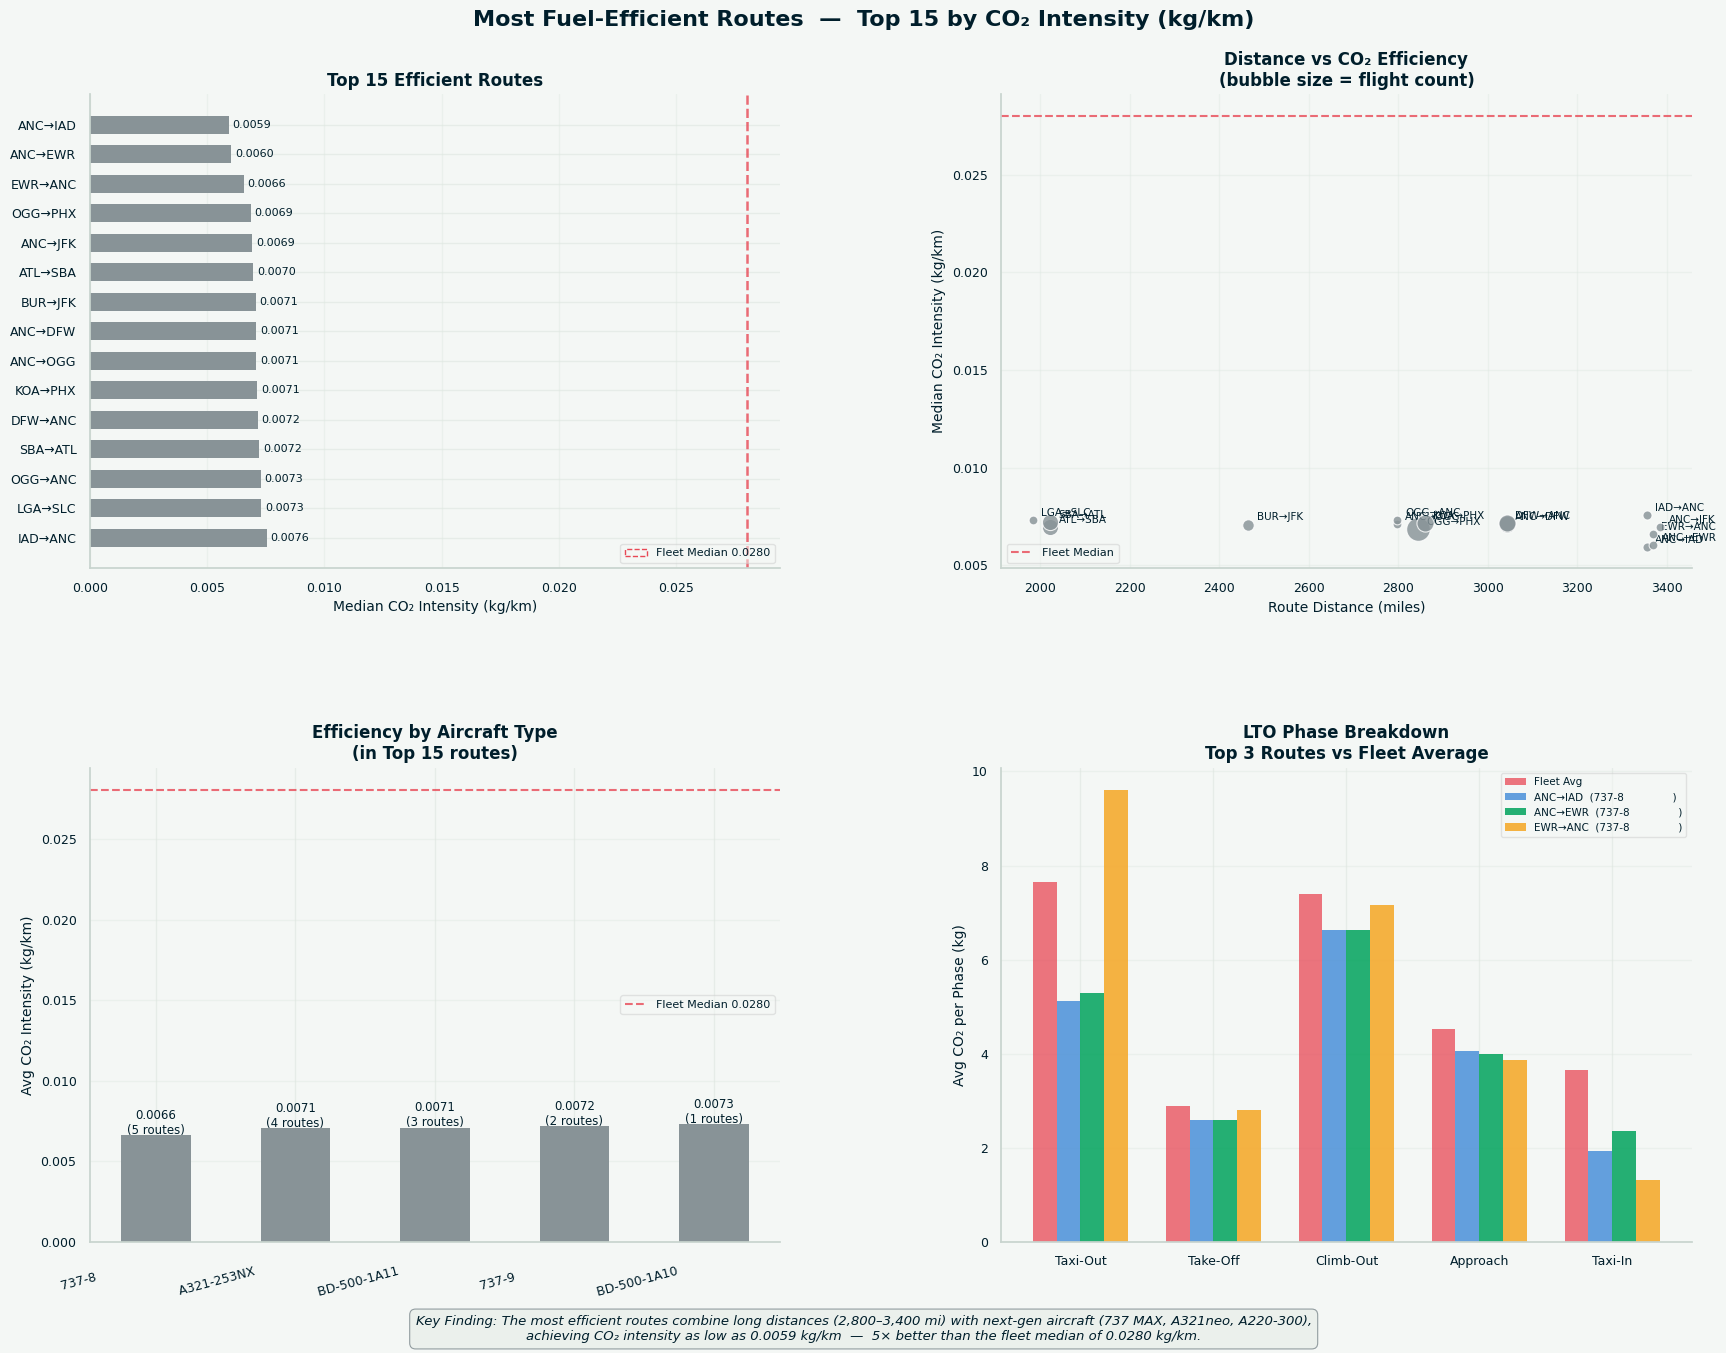

-> casestudy_efficient_routes.png


In [ ]:
"""
Case Study: Most Efficient Routes
CIVENG 160D Final Project
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

PALETTE = {
    "primary":   "#00684A",
    "secondary": "#001E2B",
    "accent":    "#00A35C",
    "warning":   "#F5A623",
    "danger":    "#E84855",
    "muted":     "#889397",
    "bg":        "#F4F7F5",
    "bg2":       "#EAF0EC",
}

OUTPUT_DIR = "./"

plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["bg"],
    "axes.edgecolor":    "#C8D4CE",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "text.color":        PALETTE["secondary"],
    "axes.labelcolor":   PALETTE["secondary"],
    "xtick.color":       PALETTE["secondary"],
    "ytick.color":       PALETTE["secondary"],
    "grid.color":        "#DDE6E0",
    "grid.alpha":        0.6,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    12,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

# ─── Aircraft name mapping ────────────────────────────────────────────────────
ACFT_NAME_MAP = {
    'BD-500-1A11': 'A220-300',
    'BD-500-1A10': 'A220-100',
    'A321-253NX':  'A321neo (PW)',
    'A321-271NX':  'A321neo (LEAP)',
    '737-8':       '737 MAX 8',
    '737-9':       '737 MAX 9',
}

ACFT_COLORS = {
    '737 MAX 8':      "#4A90D9",
    'A321neo (PW)':   PALETTE["accent"],
    'A220-300':       PALETTE["warning"],
    '737 MAX 9':      "#7B68EE",
    'A220-100':       "#E07B54",
}

def clean_acft(name):
    return ACFT_NAME_MAP.get(str(name), str(name))

def get_acft_color(name):
    cleaned = clean_acft(name)
    return ACFT_COLORS.get(cleaned, PALETTE["muted"])


# ─── Data ─────────────────────────────────────────────────────────────────────
df = pd.read_parquet("/content/40_2025_final.parquet")

CO2_COLS = ["Taxi Out CO2", "Take Off CO2", "Climb Out CO2", "Approach CO2", "Taxi In CO2"]
df["Total_CO2"]  = df[CO2_COLS].sum(axis=1)
df["CO2_per_km"] = df["Total_CO2"] / df["DISTANCE"].replace(0, np.nan)
df["ACFT MODEL CLEAN"] = df["ACFT MODEL"].apply(clean_acft)

route_eff = (
    df.groupby(["ORIGIN", "DEST"])
    .agg(
        co2_km      = ("CO2_per_km",        "median"),
        avg_dist    = ("DISTANCE",           "mean"),
        avg_co2     = ("Total_CO2",          "mean"),
        top_acft    = ("ACFT MODEL CLEAN",   lambda x: x.value_counts().index[0]),
        top_carrier = ("OP_CARRIER",         lambda x: x.value_counts().index[0]),
        count       = ("CO2_per_km",         "size")
    )
    .reset_index()
)
route_eff  = route_eff[route_eff["count"] >= 10].sort_values("co2_km")
top15      = route_eff.head(15).copy()
top15["ROUTE"] = top15["ORIGIN"] + "→" + top15["DEST"]
fleet_median = df["CO2_per_km"].median()


# ═══════════════════════════════════════════════════════════════════════════════
# Figure
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Most Fuel-Efficient Routes  —  Top 15 by CO₂ Intensity (kg/km)",
    fontsize=16, fontweight="bold", color=PALETTE["secondary"], y=0.98
)

gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.32,
                       left=0.07, right=0.96, top=0.92, bottom=0.10)

# ── 1. Horizontal bar ──
ax1 = fig.add_subplot(gs[0, 0])
colors_bar = [get_acft_color(a) for a in top15["top_acft"]]
bars = ax1.barh(
    top15["ROUTE"][::-1], top15["co2_km"][::-1],
    color=colors_bar[::-1], edgecolor="none", height=0.62
)
ax1.axvline(fleet_median, color=PALETTE["danger"], linewidth=1.8,
            linestyle="--", alpha=0.8, label=f"Fleet Median  {fleet_median:.4f}")
for bar, val in zip(bars, top15["co2_km"][::-1]):
    ax1.text(bar.get_width() + 0.00015, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=8, color=PALETTE["secondary"])

legend_patches = [mpatches.Patch(color=v, label=k, alpha=0.85)
                  for k, v in ACFT_COLORS.items() if k in top15["top_acft"].values]
ax1.legend(handles=legend_patches + [
    mpatches.Patch(color=PALETTE["danger"], linestyle="--",
                   label=f"Fleet Median {fleet_median:.4f}", fill=False)
], fontsize=8, framealpha=0.5, loc="lower right")
ax1.set_xlabel("Median CO₂ Intensity (kg/km)")
ax1.set_title("Top 15 Efficient Routes", fontweight="bold")
ax1.grid(axis="x", alpha=0.4)
ax1.set_axisbelow(True)


# ── 2. Distance vs CO2/km scatter ──
ax2 = fig.add_subplot(gs[0, 1])
for _, row in top15.iterrows():
    color = get_acft_color(row["top_acft"])
    ax2.scatter(row["avg_dist"], row["co2_km"],
                s=max(row["count"] / 2.5, 40), alpha=0.82,
                color=color, edgecolors="white", linewidths=0.8, zorder=3)
    ax2.annotate(row["ROUTE"], (row["avg_dist"], row["co2_km"]),
                 textcoords="offset points", xytext=(6, 3),
                 fontsize=7.5, color=PALETTE["secondary"])

ax2.axhline(fleet_median, color=PALETTE["danger"], linewidth=1.5,
            linestyle="--", alpha=0.8, label=f"Fleet Median")
ax2.set_xlabel("Route Distance (miles)")
ax2.set_ylabel("Median CO₂ Intensity (kg/km)")
ax2.set_title("Distance vs CO₂ Efficiency\n(bubble size = flight count)",
              fontweight="bold")
ax2.legend(fontsize=8, framealpha=0.5)
ax2.grid(alpha=0.4)
ax2.set_axisbelow(True)


# ── 3. Aircraft efficiency ──
ax3 = fig.add_subplot(gs[1, 0])
acft_summary = (
    top15.groupby("top_acft")
    .agg(routes=("ROUTE", "count"), avg_co2_km=("co2_km", "mean"))
    .sort_values("avg_co2_km")
    .reset_index()
)
colors_a = [get_acft_color(a) for a in acft_summary["top_acft"]]
bars3 = ax3.bar(acft_summary["top_acft"], acft_summary["avg_co2_km"],
                color=colors_a, edgecolor="none", width=0.5)
for bar, val, cnt in zip(bars3, acft_summary["avg_co2_km"], acft_summary["routes"]):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.00008,
             f"{val:.4f}\n({cnt} routes)",
             ha="center", fontsize=8.5, color=PALETTE["secondary"])
ax3.axhline(fleet_median, color=PALETTE["danger"], linewidth=1.5,
            linestyle="--", alpha=0.8, label=f"Fleet Median {fleet_median:.4f}")
ax3.set_ylabel("Avg CO₂ Intensity (kg/km)")
ax3.set_title("Efficiency by Aircraft Type\n(in Top 15 routes)", fontweight="bold")
ax3.set_xticklabels(acft_summary["top_acft"], rotation=15, ha="right")
ax3.legend(fontsize=8, framealpha=0.5)
ax3.grid(axis="y", alpha=0.4)
ax3.set_axisbelow(True)


# ── 4. LTO phase breakdown ──
ax4 = fig.add_subplot(gs[1, 1])
phase_cols   = ["Taxi Out CO2", "Take Off CO2", "Climb Out CO2", "Approach CO2", "Taxi In CO2"]
phase_labels = ["Taxi-Out", "Take-Off", "Climb-Out", "Approach", "Taxi-In"]

top3 = top15.head(3)
n_groups = len(phase_labels)
n_bars   = 4  # fleet + 3 routes
width    = 0.18
x        = np.arange(n_groups)

fleet_phases = df[phase_cols].mean().values
ax4.bar(x - width*1.5, fleet_phases, width,
        label="Fleet Avg", color=PALETTE["danger"],
        edgecolor="none", alpha=0.75)

route_colors_list = ["#4A90D9", PALETTE["accent"], PALETTE["warning"]]
for i, (_, row) in enumerate(top3.iterrows()):
    rdata = df[(df["ORIGIN"] == row["ORIGIN"]) &
               (df["DEST"]   == row["DEST"])][phase_cols].mean().values
    ax4.bar(x + width*(i - 0.5), rdata, width,
            label=f"{row['ROUTE']}  ({row['top_acft']})",
            color=route_colors_list[i], edgecolor="none", alpha=0.85)

ax4.set_xticks(x)
ax4.set_xticklabels(phase_labels, fontsize=9)
ax4.set_ylabel("Avg CO₂ per Phase (kg)")
ax4.set_title("LTO Phase Breakdown\nTop 3 Routes vs Fleet Average", fontweight="bold")
ax4.legend(fontsize=7.5, framealpha=0.5, loc="upper right")
ax4.grid(axis="y", alpha=0.4)
ax4.set_axisbelow(True)


# ── Bottom insight ──
ratio = fleet_median / top15["co2_km"].min()
fig.text(
    0.5, 0.03,
    f"Key Finding: The most efficient routes combine long distances (2,800–3,400 mi) with "
    f"next-gen aircraft (737 MAX, A321neo, A220-300),\n"
    f"achieving CO₂ intensity as low as {top15['co2_km'].min():.4f} kg/km  —  "
    f"{ratio:.0f}× better than the fleet median of {fleet_median:.4f} kg/km.",
    ha="center", fontsize=9.5, style="italic", color=PALETTE["secondary"],
    bbox=dict(boxstyle="round,pad=0.45", facecolor=PALETTE["bg2"],
              alpha=0.9, edgecolor=PALETTE["muted"], linewidth=0.8)
)

plt.savefig(f"{OUTPUT_DIR}casestudy_efficient_routes.png",
            dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("-> casestudy_efficient_routes.png")

In [ ]:
# 가장 CO2/km 높은 노선 분석
worst15 = route_eff.tail(15).sort_values("co2_km", ascending=False).copy()
worst15["ROUTE"] = worst15["ORIGIN"] + "→" + worst15["DEST"]
worst15["ACFT MODEL CLEAN"] = worst15["top_acft"].apply(clean_acft)

print("=== Top 15 Least Efficient Routes (highest CO2/km) ===")
print(worst15[["ROUTE", "co2_km", "avg_dist", "avg_co2",
               "top_acft", "top_carrier", "count"]].to_string())

print(f"\nFleet Median CO2/km: {fleet_median:.4f}")

=== Top 15 Least Efficient Routes (highest CO2/km) ===
       ROUTE    co2_km    avg_dist    avg_co2              top_acft top_carrier  count
331  KOA→OGG  0.219975   84.000000  18.877300  717-200                       HA   1064
423  OGG→KOA  0.205792   84.000000  17.652371  717-200                       HA   1100
265  HNL→OGG  0.194131  100.481955  19.798393  717-200                       HA   7897
422  OGG→HNL  0.181095  100.482750  18.393528  717-200                       HA   7884
48   AVL→CLT  0.177228   91.000000  18.010300  CL-600-2D24                   OH   1905
551  SBA→LAX  0.165703   89.000000  15.332029  ERJ 170-200 LL                OO    651
104  CLT→AVL  0.160322   91.000000  16.499404  CL-600-2D24                   OH   1904
360  LAX→SBA  0.157054   89.000000  14.351236  ERJ 170-200 LL                OO    651
497  PHL→LGA  0.149118   96.000000  14.935757  ERJ 170-200 LR                YX    258
375  LGA→PHL  0.144341   96.000000  14.847229  ERJ 170-200 LR              

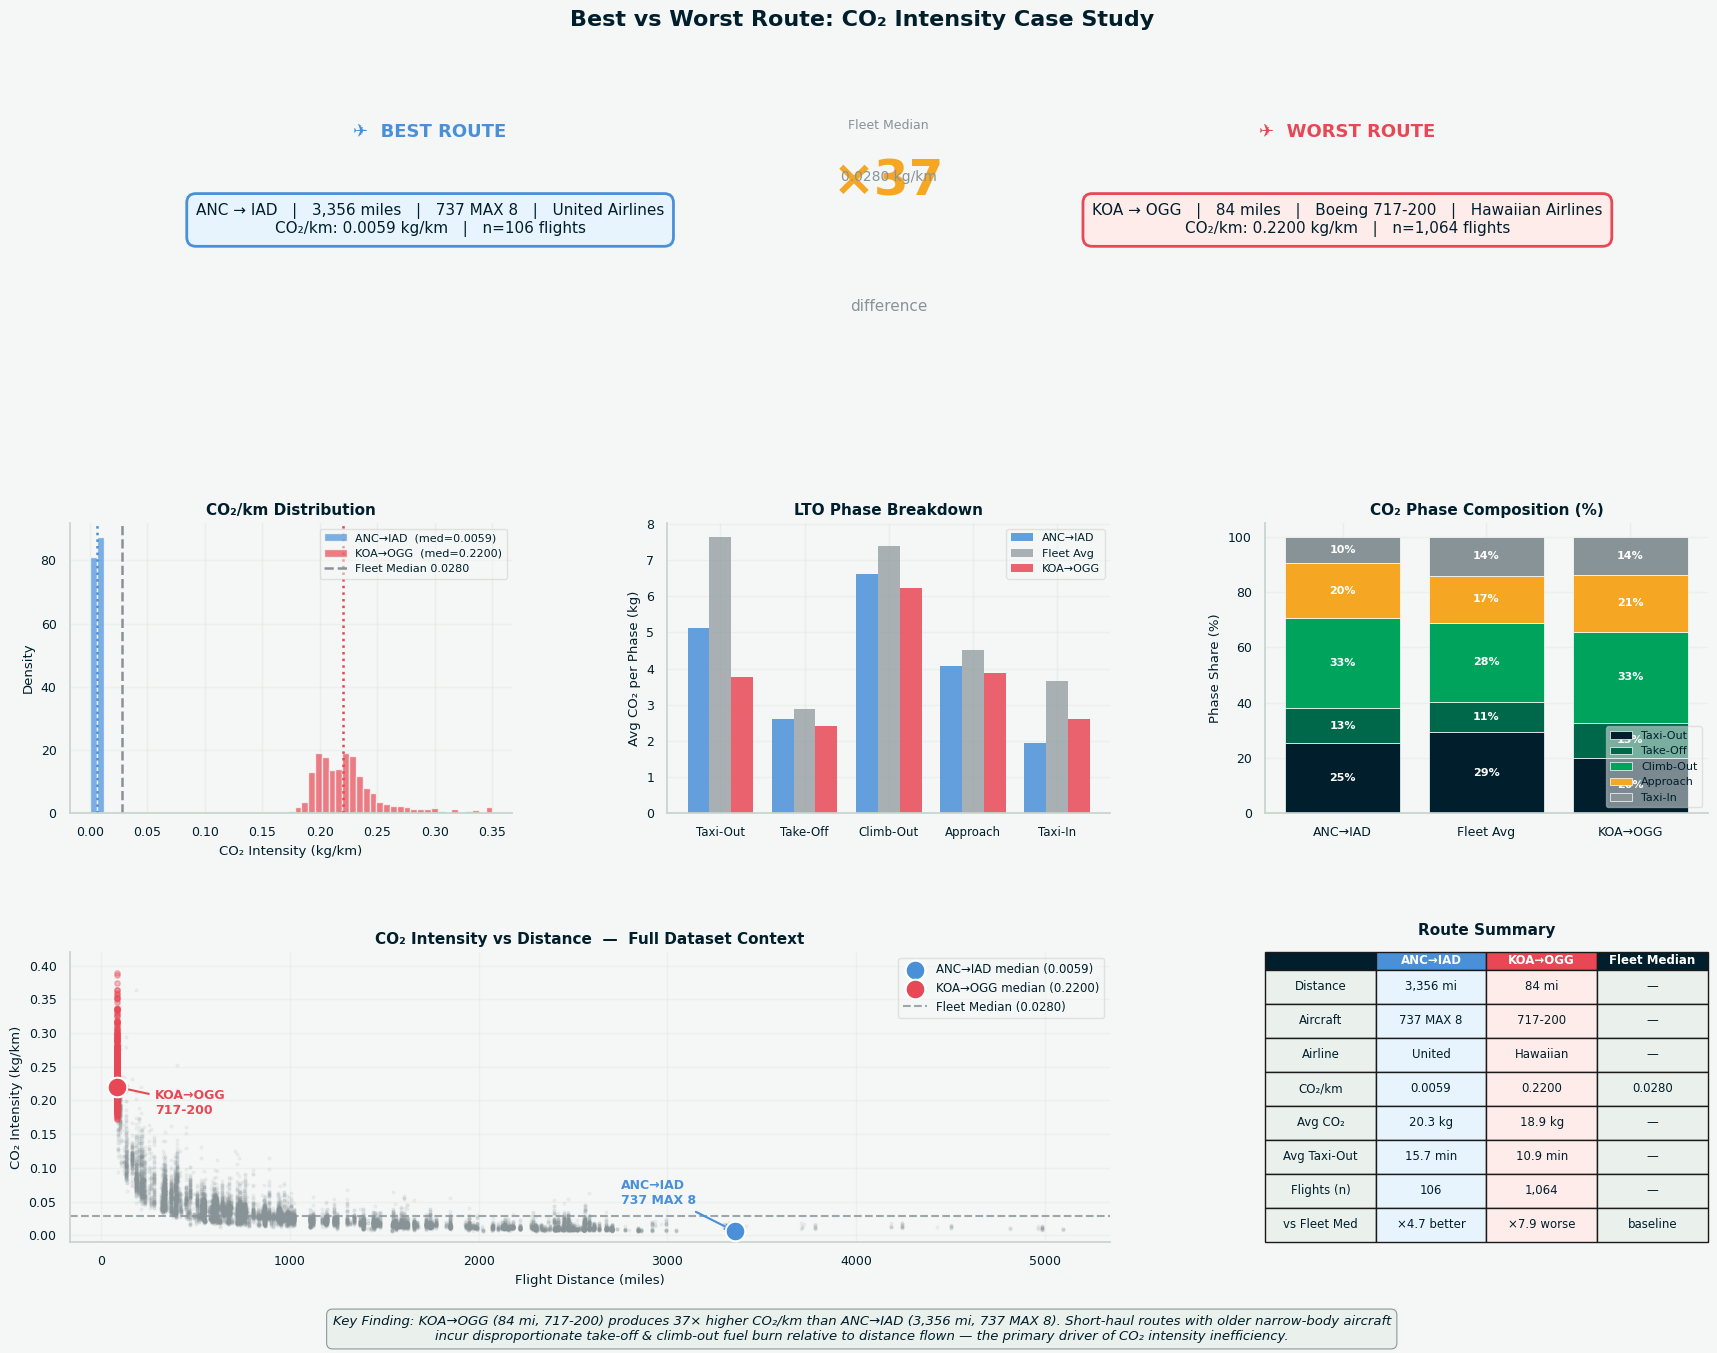

-> casestudy_best_vs_worst.png


In [ ]:
"""
Case Study: Best vs Worst Route — CO2 Intensity Comparison
ANC→IAD (Best) vs KOA→OGG (Worst)
CIVENG 160D Final Project
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

PALETTE = {
    "primary":   "#00684A",
    "secondary": "#001E2B",
    "accent":    "#00A35C",
    "warning":   "#F5A623",
    "danger":    "#E84855",
    "muted":     "#889397",
    "bg":        "#F4F7F5",
    "bg2":       "#EAF0EC",
    "best":      "#4A90D9",
    "worst":     "#E84855",
    "fleet":     "#889397",
}

OUTPUT_DIR = "./"

plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["bg"],
    "axes.edgecolor":    "#C8D4CE",
    "text.color":        PALETTE["secondary"],
    "axes.labelcolor":   PALETTE["secondary"],
    "xtick.color":       PALETTE["secondary"],
    "ytick.color":       PALETTE["secondary"],
    "grid.color":        "#DDE6E0",
    "grid.alpha":        0.5,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    11,
    "axes.labelsize":    9.5,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ─── Data ─────────────────────────────────────────────────────────────────────
df = pd.read_parquet("/content/40_2025_final.parquet")

CO2_COLS   = ["Taxi Out CO2", "Take Off CO2", "Climb Out CO2", "Approach CO2", "Taxi In CO2"]
PHASE_LBLS = ["Taxi-Out", "Take-Off", "Climb-Out", "Approach", "Taxi-In"]

df["Total_CO2"]  = df[CO2_COLS].sum(axis=1)
df["CO2_per_km"] = df["Total_CO2"] / df["DISTANCE"].replace(0, np.nan)

best  = df[(df["ORIGIN"] == "ANC") & (df["DEST"] == "IAD")].copy()
worst = df[(df["ORIGIN"] == "KOA") & (df["DEST"] == "OGG")].copy()
fleet_median = df["CO2_per_km"].median()

best_med  = best["CO2_per_km"].median()
worst_med = worst["CO2_per_km"].median()
ratio     = worst_med / best_med


# ═══════════════════════════════════════════════════════════════════════════════
# Figure layout
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Best vs Worst Route: CO₂ Intensity Case Study",
    fontsize=16, fontweight="bold", color=PALETTE["secondary"], y=0.98
)

gs = gridspec.GridSpec(3, 3, figure=fig,
                        hspace=0.48, wspace=0.35,
                        left=0.06, right=0.97,
                        top=0.92, bottom=0.10)


# ── 1. Route profile cards (top row spanning all) ──────────────────────────
ax_info = fig.add_subplot(gs[0, :])
ax_info.axis("off")

# Best card
best_card = dict(boxstyle="round,pad=0.6", facecolor="#E8F4FD",
                 edgecolor=PALETTE["best"], linewidth=2)
worst_card = dict(boxstyle="round,pad=0.6", facecolor="#FDECEA",
                  edgecolor=PALETTE["worst"], linewidth=2)

ax_info.text(0.22, 0.85, "✈  BEST ROUTE", ha="center", fontsize=13,
             fontweight="bold", color=PALETTE["best"], transform=ax_info.transAxes)
ax_info.text(0.22, 0.52,
             f"ANC → IAD   |   3,356 miles   |   737 MAX 8   |   United Airlines\n"
             f"CO₂/km: {best_med:.4f} kg/km   |   n={len(best):,} flights",
             ha="center", fontsize=11, color=PALETTE["secondary"],
             transform=ax_info.transAxes,
             bbox=best_card)

ax_info.text(0.78, 0.85, "✈  WORST ROUTE", ha="center", fontsize=13,
             fontweight="bold", color=PALETTE["worst"], transform=ax_info.transAxes)
ax_info.text(0.78, 0.52,
             f"KOA → OGG   |   84 miles   |   Boeing 717-200   |   Hawaiian Airlines\n"
             f"CO₂/km: {worst_med:.4f} kg/km   |   n={len(worst):,} flights",
             ha="center", fontsize=11, color=PALETTE["secondary"],
             transform=ax_info.transAxes,
             bbox=worst_card)

# Ratio badge
ax_info.text(0.50, 0.65, f"×{ratio:.0f}", ha="center", fontsize=36,
             fontweight="bold", color=PALETTE["warning"],
             transform=ax_info.transAxes)
ax_info.text(0.50, 0.25, "difference", ha="center", fontsize=11,
             color=PALETTE["muted"], transform=ax_info.transAxes)
ax_info.text(0.50, 0.88, "Fleet Median", ha="center", fontsize=9,
             color=PALETTE["muted"], transform=ax_info.transAxes)
ax_info.text(0.50, 0.70, f"{fleet_median:.4f} kg/km",
             ha="center", fontsize=10, color=PALETTE["muted"],
             transform=ax_info.transAxes)


# ── 2. CO2/km distribution comparison ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

bins = np.linspace(0, 0.35, 60)
ax2.hist(best["CO2_per_km"].clip(upper=0.35),  bins=bins,
         color=PALETTE["best"],  alpha=0.7, label=f"ANC→IAD  (med={best_med:.4f})",  density=True)
ax2.hist(worst["CO2_per_km"].clip(upper=0.35), bins=bins,
         color=PALETTE["worst"], alpha=0.7, label=f"KOA→OGG  (med={worst_med:.4f})", density=True)
ax2.axvline(fleet_median, color=PALETTE["fleet"], linewidth=1.8,
            linestyle="--", label=f"Fleet Median {fleet_median:.4f}")
ax2.axvline(best_med,  color=PALETTE["best"],  linewidth=1.8, linestyle=":")
ax2.axvline(worst_med, color=PALETTE["worst"], linewidth=1.8, linestyle=":")

ax2.set_xlabel("CO₂ Intensity (kg/km)")
ax2.set_ylabel("Density")
ax2.set_title("CO₂/km Distribution", fontweight="bold")
ax2.legend(fontsize=8, framealpha=0.5)
ax2.grid(axis="y", alpha=0.4); ax2.set_axisbelow(True)


# ── 3. LTO phase CO2 comparison ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

best_phases  = best[CO2_COLS].mean().values
worst_phases = worst[CO2_COLS].mean().values
fleet_phases = df[CO2_COLS].mean().values

x     = np.arange(len(PHASE_LBLS))
width = 0.26

ax3.bar(x - width, best_phases,  width, label="ANC→IAD",   color=PALETTE["best"],  alpha=0.85, edgecolor="none")
ax3.bar(x,         fleet_phases, width, label="Fleet Avg",  color=PALETTE["fleet"], alpha=0.7,  edgecolor="none")
ax3.bar(x + width, worst_phases, width, label="KOA→OGG",   color=PALETTE["worst"], alpha=0.85, edgecolor="none")

ax3.set_xticks(x)
ax3.set_xticklabels(PHASE_LBLS, fontsize=8.5)
ax3.set_ylabel("Avg CO₂ per Phase (kg)")
ax3.set_title("LTO Phase Breakdown", fontweight="bold")
ax3.legend(fontsize=8, framealpha=0.5)
ax3.grid(axis="y", alpha=0.4); ax3.set_axisbelow(True)


# ── 4. Phase CO2 share (stacked 100%) ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])

phase_colors_list = [PALETTE["secondary"], PALETTE["primary"],
                     PALETTE["accent"], PALETTE["warning"], PALETTE["muted"]]

routes_labels = ["ANC→IAD", "Fleet Avg", "KOA→OGG"]
data_matrix   = np.array([best_phases, fleet_phases, worst_phases])
data_pct      = data_matrix / data_matrix.sum(axis=1, keepdims=True) * 100

bottoms = np.zeros(3)
for i, (phase, color) in enumerate(zip(PHASE_LBLS, phase_colors_list)):
    ax4.bar(routes_labels, data_pct[:, i], bottom=bottoms,
            label=phase, color=color, edgecolor="white", linewidth=0.5)
    for j, (val, bot) in enumerate(zip(data_pct[:, i], bottoms)):
        if val > 5:
            ax4.text(j, bot + val/2, f"{val:.0f}%",
                     ha="center", va="center", fontsize=8,
                     color="white", fontweight="bold")
    bottoms += data_pct[:, i]

ax4.set_ylabel("Phase Share (%)")
ax4.set_title("CO₂ Phase Composition (%)", fontweight="bold")
ax4.legend(fontsize=8, loc="lower right", framealpha=0.5)
ax4.set_ylim(0, 105)
ax4.grid(axis="y", alpha=0.4); ax4.set_axisbelow(True)


# ── 5. CO2/km vs Distance context ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])

sample = df.sample(min(15000, len(df)), random_state=42)
ax5.scatter(sample["DISTANCE"], sample["CO2_per_km"].clip(upper=0.4),
            alpha=0.08, s=4, color=PALETTE["muted"], zorder=1)

# Best & worst clouds
ax5.scatter(best["DISTANCE"],  best["CO2_per_km"].clip(upper=0.4),
            alpha=0.35, s=15, color=PALETTE["best"],  zorder=2)
ax5.scatter(worst["DISTANCE"], worst["CO2_per_km"].clip(upper=0.4),
            alpha=0.35, s=15, color=PALETTE["worst"], zorder=2)

# Median markers
ax5.scatter(best["DISTANCE"].mean(),  best_med,
            s=200, color=PALETTE["best"],  zorder=4,
            edgecolors="white", linewidths=1.5,
            label=f"ANC→IAD median ({best_med:.4f})")
ax5.scatter(worst["DISTANCE"].mean(), worst_med,
            s=200, color=PALETTE["worst"], zorder=4,
            edgecolors="white", linewidths=1.5,
            label=f"KOA→OGG median ({worst_med:.4f})")
ax5.axhline(fleet_median, color=PALETTE["fleet"], linewidth=1.5,
            linestyle="--", label=f"Fleet Median ({fleet_median:.4f})", alpha=0.8)

ax5.annotate("ANC→IAD\n737 MAX 8",
             xy=(best["DISTANCE"].mean(), best_med),
             xytext=(best["DISTANCE"].mean() - 600, best_med + 0.04),
             arrowprops=dict(arrowstyle="->", color=PALETTE["best"], lw=1.5),
             fontsize=9, color=PALETTE["best"], fontweight="bold")
ax5.annotate("KOA→OGG\n717-200",
             xy=(worst["DISTANCE"].mean(), worst_med),
             xytext=(worst["DISTANCE"].mean() + 200, worst_med - 0.04),
             arrowprops=dict(arrowstyle="->", color=PALETTE["worst"], lw=1.5),
             fontsize=9, color=PALETTE["worst"], fontweight="bold")

ax5.set_xlabel("Flight Distance (miles)")
ax5.set_ylabel("CO₂ Intensity (kg/km)")
ax5.set_title("CO₂ Intensity vs Distance  —  Full Dataset Context",
              fontweight="bold")
ax5.legend(fontsize=8.5, framealpha=0.5, loc="upper right")
ax5.grid(alpha=0.4); ax5.set_axisbelow(True)
ax5.set_ylim(-0.01, 0.42)


# ── 6. Summary stats table ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")

rows = [
    ["",              "ANC→IAD",           "KOA→OGG",           "Fleet Median"],
    ["Distance",      "3,356 mi",          "84 mi",             "—"],
    ["Aircraft",      "737 MAX 8",         "717-200",           "—"],
    ["Airline",       "United",            "Hawaiian",          "—"],
    ["CO₂/km",        f"{best_med:.4f}",   f"{worst_med:.4f}",  f"{fleet_median:.4f}"],
    ["Avg CO₂",       f"{best['Total_CO2'].mean():.1f} kg",
                      f"{worst['Total_CO2'].mean():.1f} kg",    "—"],
    ["Avg Taxi-Out",  f"{best['TAXI_OUT'].mean():.1f} min",
                      f"{worst['TAXI_OUT'].mean():.1f} min",    "—"],
    ["Flights (n)",   f"{len(best):,}",    f"{len(worst):,}",   "—"],
    ["vs Fleet Med",  f"×{fleet_median/best_med:.1f} better",
                      f"×{worst_med/fleet_median:.1f} worse",   "baseline"],
]

col_colors = [
    [PALETTE["bg2"]] * 4,
    *[[PALETTE["bg2"], "#E8F4FD", "#FDECEA", "#F5F5F5"]] * (len(rows) - 1)
]

tbl = ax6.table(
    cellText=rows[1:],
    colLabels=rows[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)

for j in range(4):
    tbl[0, j].set_facecolor(PALETTE["secondary"])
    tbl[0, j].set_text_props(color="white", fontweight="bold")
    if j == 1: tbl[0, j].set_facecolor(PALETTE["best"])
    if j == 2: tbl[0, j].set_facecolor(PALETTE["worst"])

for i in range(1, len(rows)):
    for j in range(4):
        tbl[i, j].set_facecolor(
            "#E8F4FD" if j == 1 else
            "#FDECEA" if j == 2 else
            PALETTE["bg2"]
        )
        tbl[i, j].set_height(0.11)

ax6.set_title("Route Summary", fontweight="bold", pad=12)


# ── Bottom insight ─────────────────────────────────────────────────────────
fig.text(
    0.5, 0.03,
    f"Key Finding: KOA→OGG (84 mi, 717-200) produces {ratio:.0f}× higher CO₂/km than ANC→IAD (3,356 mi, 737 MAX 8). "
    f"Short-haul routes with older narrow-body aircraft\n"
    f"incur disproportionate take-off & climb-out fuel burn relative to distance flown — "
    f"the primary driver of CO₂ intensity inefficiency.",
    ha="center", fontsize=9.5, style="italic", color=PALETTE["secondary"],
    bbox=dict(boxstyle="round,pad=0.45", facecolor=PALETTE["bg2"],
              alpha=0.95, edgecolor=PALETTE["muted"], linewidth=0.8)
)

plt.savefig(f"{OUTPUT_DIR}casestudy_best_vs_worst.png",
            dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("-> casestudy_best_vs_worst.png")


In [ ]:
# KOA→OGG 워스트 케이스 데이터 확인
worst_route = df[(df["ORIGIN"] == "KOA") & (df["DEST"] == "OGG")].copy()

print(f"총 편수: {len(worst_route)}")
print(f"\nCO2/km 통계:")
print(worst_route["CO2_per_km"].describe().round(4))

print(f"\n항공기 717-200 전체 평균:")
b717 = df[df["ACFT MODEL"].str.contains("717", na=False)]
print(f"  CO2/km median: {b717['CO2_per_km'].median():.4f}")
print(f"  편수: {len(b717):,}")

print(f"\n시간대별 CO2/km:")
worst_route["HOUR"] = (worst_route["CRS_DEP_TIME"] // 100)
print(worst_route.groupby("HOUR")["CO2_per_km"].agg(["mean","count"]).round(4))

print(f"\n상위 10편 샘플:")
sample_cols = ["FL_DATE","TAIL_NUM","ACFT MODEL","TAXI_OUT","Total_CO2","CO2_per_km"]
print(worst_route.nlargest(10, "CO2_per_km")[sample_cols].to_string())

총 편수: 1064

CO2/km 통계:
count    1064.0000
mean        0.2247
std         0.0313
min         0.1726
25%         0.2032
50%         0.2200
75%         0.2349
max         0.3891
Name: CO2_per_km, dtype: float64

항공기 717-200 전체 평균:
  CO2/km median: 0.1294
  편수: 23,360

시간대별 CO2/km:
        mean  count
HOUR               
7     0.2363      8
8     0.2085    190
9     0.2119     37
10    0.2081    153
11    0.2161     95
12    0.2290    161
13    0.2383    350
14    0.2449     65
16    0.2456      4
17    0.2364      1

상위 10편 샘플:
           FL_DATE TAIL_NUM            ACFT MODEL  TAXI_OUT  Total_CO2  CO2_per_km
961099  2025-08-01   N494HA  717-200                    7.0  32.680816    0.389057
1175700 2025-10-25   N494HA  717-200                   14.0  32.439865    0.386189
483636  2025-04-23   N485HA  717-200                   49.0  31.488888    0.374868
335871  2025-03-18   N494HA  717-200                   12.0  30.585649    0.364115
365744  2025-04-19   N8309C  737-8H4                  

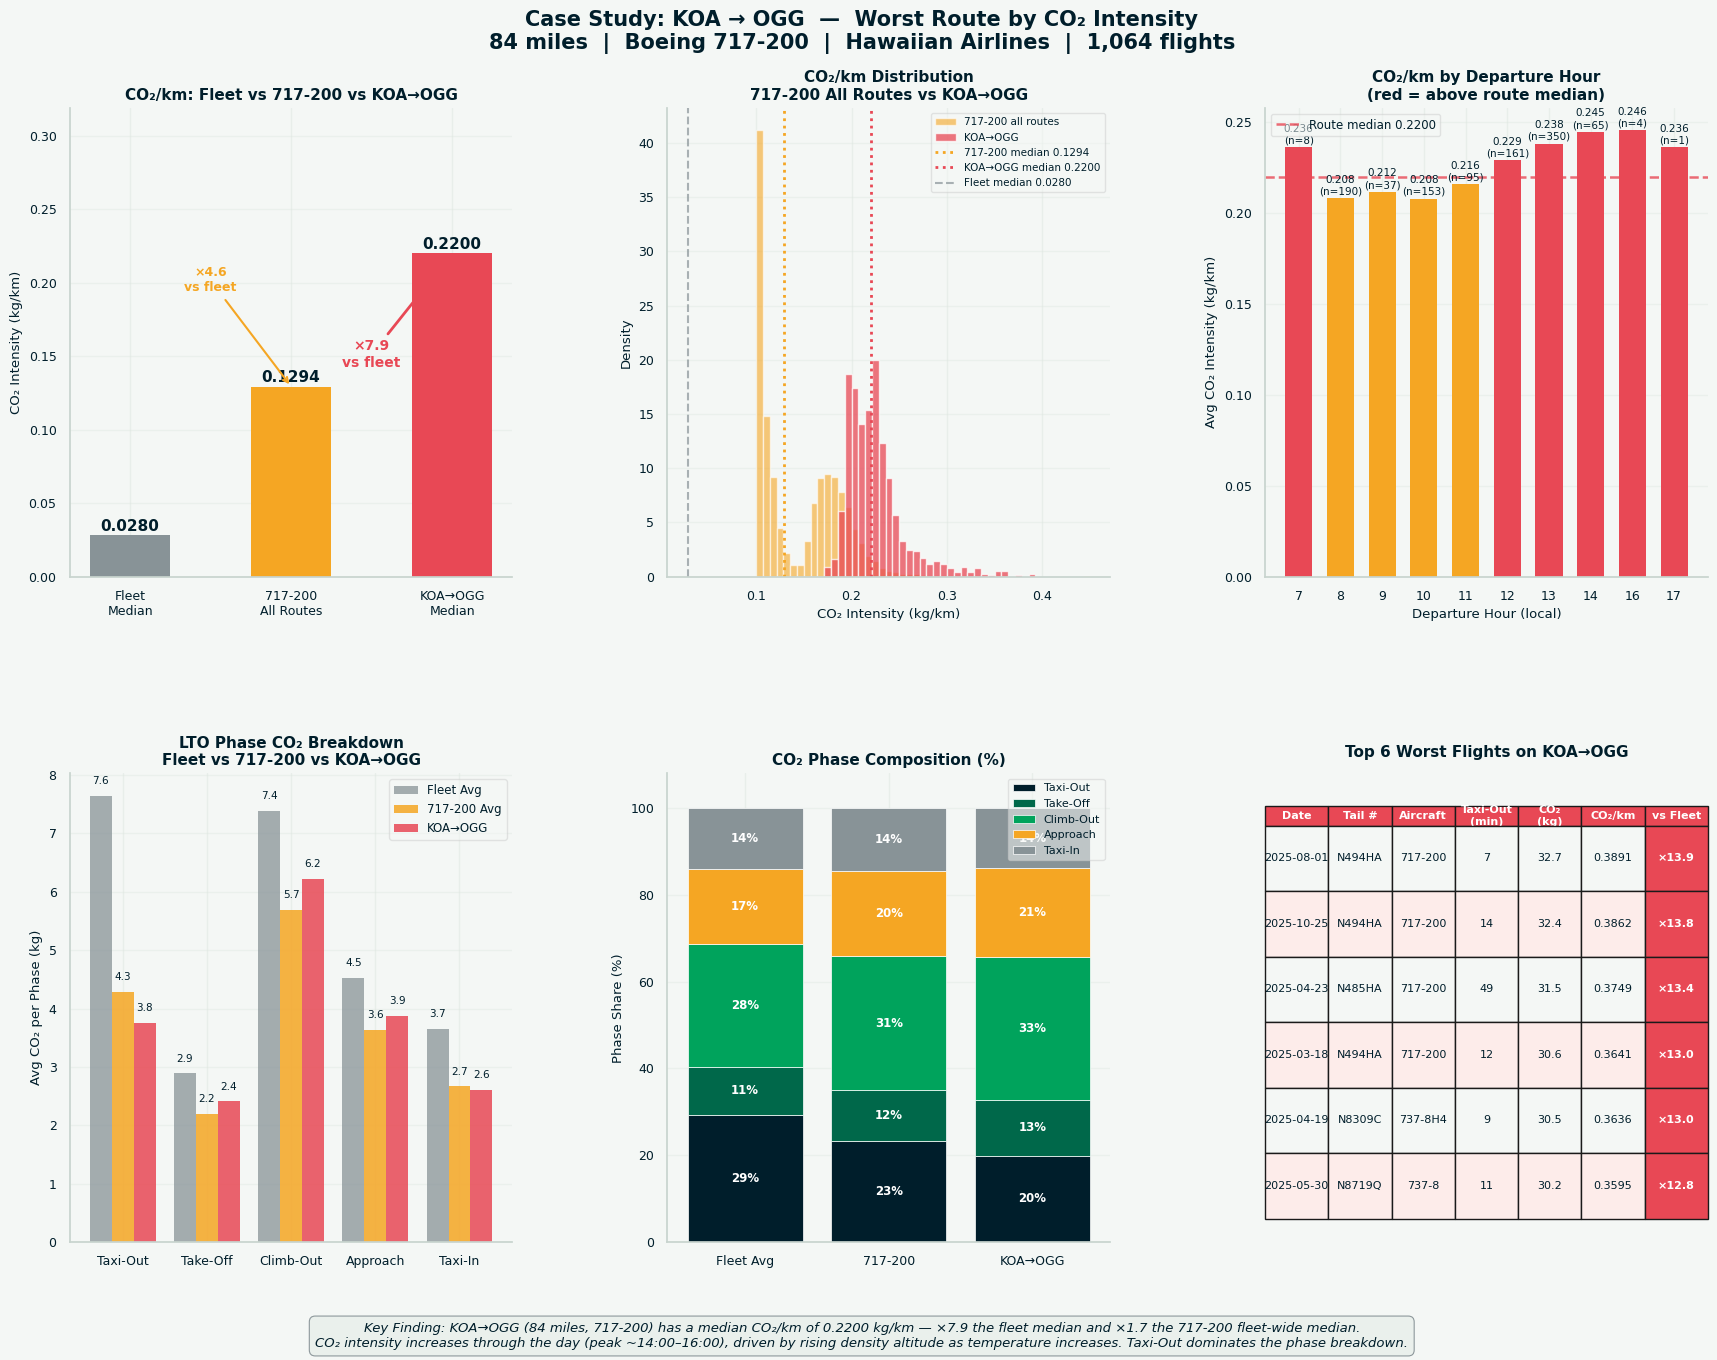

-> casestudy_koa_ogg.png


In [ ]:
"""
Case Study: KOA→OGG — Worst Route
CIVENG 160D Final Project
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

PALETTE = {
    "primary":   "#00684A",
    "secondary": "#001E2B",
    "accent":    "#00A35C",
    "warning":   "#F5A623",
    "danger":    "#E84855",
    "muted":     "#889397",
    "bg":        "#F4F7F5",
    "bg2":       "#EAF0EC",
    "worst":     "#E84855",
    "fleet":     "#889397",
    "acft":      "#F5A623",
}

OUTPUT_DIR = "./"
plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["bg"],
    "axes.edgecolor":    "#C8D4CE",
    "text.color":        PALETTE["secondary"],
    "axes.labelcolor":   PALETTE["secondary"],
    "xtick.color":       PALETTE["secondary"],
    "ytick.color":       PALETTE["secondary"],
    "grid.color":        "#DDE6E0",
    "grid.alpha":        0.5,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    11,
    "axes.labelsize":    9.5,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ─── Data ─────────────────────────────────────────────────────────────────────
df = pd.read_parquet("/content/40_2025_final.parquet")

CO2_COLS   = ["Taxi Out CO2", "Take Off CO2", "Climb Out CO2", "Approach CO2", "Taxi In CO2"]
PHASE_LBLS = ["Taxi-Out", "Take-Off", "Climb-Out", "Approach", "Taxi-In"]
PHASE_COLS_LIST = [
    [PALETTE["secondary"], PALETTE["primary"],
     PALETTE["accent"], PALETTE["warning"], PALETTE["muted"]]
]

df["Total_CO2"]  = df[CO2_COLS].sum(axis=1)
df["CO2_per_km"] = df["Total_CO2"] / df["DISTANCE"].replace(0, np.nan)

route    = df[(df["ORIGIN"] == "KOA") & (df["DEST"] == "OGG")].copy()
b717     = df[df["ACFT MODEL"].str.contains("717", na=False)].copy()
route["HOUR"] = route["CRS_DEP_TIME"] // 100

fleet_med = df["CO2_per_km"].median()
acft_med  = b717["CO2_per_km"].median()
route_med = route["CO2_per_km"].median()

top_flights = route.nlargest(6, "CO2_per_km")[
    ["FL_DATE", "TAIL_NUM", "ACFT MODEL", "TAXI_OUT", "Total_CO2", "CO2_per_km"]
].copy()
top_flights["vs_fleet"] = top_flights["CO2_per_km"] / fleet_med


# ═══════════════════════════════════════════════════════════════════════════════
# Figure
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Case Study: KOA → OGG  —  Worst Route by CO₂ Intensity\n"
    "84 miles  |  Boeing 717-200  |  Hawaiian Airlines  |  1,064 flights",
    fontsize=15, fontweight="bold", color=PALETTE["secondary"], y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.42, wspace=0.35,
                        left=0.06, right=0.97,
                        top=0.91, bottom=0.10)


# ── 1. CO2/km comparison: Fleet / 717-200 / KOA→OGG ──
ax1 = fig.add_subplot(gs[0, 0])
categories = ["Fleet\nMedian", "717-200\nAll Routes", "KOA→OGG\nMedian"]
values     = [fleet_med, acft_med, route_med]
colors     = [PALETTE["fleet"], PALETTE["acft"], PALETTE["worst"]]
bars = ax1.bar(categories, values, color=colors, edgecolor="none", width=0.5)

for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.4f}", ha="center", fontsize=11, fontweight="bold",
             color=PALETTE["secondary"])

# Multiplier arrows
ax1.annotate(
    f"×{route_med/fleet_med:.1f}\nvs fleet",
    xy=(2, route_med), xytext=(1.5, route_med * 0.65),
    arrowprops=dict(arrowstyle="->", color=PALETTE["worst"], lw=2),
    fontsize=10, color=PALETTE["worst"], fontweight="bold", ha="center"
)
ax1.annotate(
    f"×{acft_med/fleet_med:.1f}\nvs fleet",
    xy=(1, acft_med), xytext=(0.5, acft_med * 1.5),
    arrowprops=dict(arrowstyle="->", color=PALETTE["acft"], lw=1.5),
    fontsize=9, color=PALETTE["acft"], fontweight="bold", ha="center"
)

ax1.set_ylabel("CO₂ Intensity (kg/km)")
ax1.set_title("CO₂/km: Fleet vs 717-200 vs KOA→OGG", fontweight="bold")
ax1.set_ylim(0, route_med * 1.45)
ax1.grid(axis="y", alpha=0.4); ax1.set_axisbelow(True)


# ── 2. CO2/km distribution (KOA→OGG vs 717-200 overall) ──
ax2 = fig.add_subplot(gs[0, 1])
bins = np.linspace(0.10, 0.45, 50)
ax2.hist(b717["CO2_per_km"].clip(0.10, 0.45), bins=bins,
         color=PALETTE["acft"], alpha=0.6, label="717-200 all routes", density=True)
ax2.hist(route["CO2_per_km"].clip(0.10, 0.45), bins=bins,
         color=PALETTE["worst"], alpha=0.75, label="KOA→OGG", density=True)
ax2.axvline(acft_med,  color=PALETTE["acft"],  linewidth=2, linestyle=":",
            label=f"717-200 median {acft_med:.4f}")
ax2.axvline(route_med, color=PALETTE["worst"], linewidth=2, linestyle=":",
            label=f"KOA→OGG median {route_med:.4f}")
ax2.axvline(fleet_med, color=PALETTE["fleet"], linewidth=1.5, linestyle="--",
            label=f"Fleet median {fleet_med:.4f}", alpha=0.7)
ax2.set_xlabel("CO₂ Intensity (kg/km)")
ax2.set_ylabel("Density")
ax2.set_title("CO₂/km Distribution\n717-200 All Routes vs KOA→OGG", fontweight="bold")
ax2.legend(fontsize=7.5, framealpha=0.5)
ax2.grid(axis="y", alpha=0.4); ax2.set_axisbelow(True)


# ── 3. Hourly CO2/km ──
ax3 = fig.add_subplot(gs[0, 2])
hourly = route.groupby("HOUR")["CO2_per_km"].agg(["mean","count"]).reset_index()
hourly.columns = ["HOUR", "mean", "count"]

bar_colors = [PALETTE["worst"] if v > route_med else PALETTE["acft"]
              for v in hourly["mean"]]
bars3 = ax3.bar(hourly["HOUR"].astype(str), hourly["mean"],
                color=bar_colors, edgecolor="none", width=0.65)
for bar, val, cnt in zip(bars3, hourly["mean"], hourly["count"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.3f}\n(n={cnt})", ha="center", fontsize=7.5,
             color=PALETTE["secondary"])

ax3.axhline(route_med, color=PALETTE["worst"], linewidth=1.8, linestyle="--",
            alpha=0.8, label=f"Route median {route_med:.4f}")
ax3.set_xlabel("Departure Hour (local)")
ax3.set_ylabel("Avg CO₂ Intensity (kg/km)")
ax3.set_title("CO₂/km by Departure Hour\n(red = above route median)",
              fontweight="bold")
ax3.legend(fontsize=8.5, framealpha=0.5)
ax3.grid(axis="y", alpha=0.4); ax3.set_axisbelow(True)


# ── 4. LTO phase breakdown ──
ax4 = fig.add_subplot(gs[1, 0])
route_phases  = route[CO2_COLS].mean().values
b717_phases   = b717[CO2_COLS].mean().values
fleet_phases  = df[CO2_COLS].mean().values

x = np.arange(len(PHASE_LBLS))
w = 0.26
ax4.bar(x - w, fleet_phases,  w, label="Fleet Avg",    color=PALETTE["fleet"], alpha=0.75, edgecolor="none")
ax4.bar(x,     b717_phases,   w, label="717-200 Avg",  color=PALETTE["acft"],  alpha=0.85, edgecolor="none")
ax4.bar(x + w, route_phases,  w, label="KOA→OGG",      color=PALETTE["worst"], alpha=0.85, edgecolor="none")

for bars_grp, vals in [(x - w, fleet_phases), (x, b717_phases), (x + w, route_phases)]:
    for xi, val in zip(bars_grp, vals):
        ax4.text(xi, val + 0.2, f"{val:.1f}", ha="center", fontsize=7.5,
                 color=PALETTE["secondary"])

ax4.set_xticks(x)
ax4.set_xticklabels(PHASE_LBLS, fontsize=9)
ax4.set_ylabel("Avg CO₂ per Phase (kg)")
ax4.set_title("LTO Phase CO₂ Breakdown\nFleet vs 717-200 vs KOA→OGG", fontweight="bold")
ax4.legend(fontsize=8.5, framealpha=0.5)
ax4.grid(axis="y", alpha=0.4); ax4.set_axisbelow(True)


# ── 5. Phase share 100% stacked ──
ax5 = fig.add_subplot(gs[1, 1])
phase_colors_list = [PALETTE["secondary"], PALETTE["primary"],
                     PALETTE["accent"], PALETTE["warning"], PALETTE["muted"]]
labels_3 = ["Fleet Avg", "717-200", "KOA→OGG"]
data3 = np.array([fleet_phases, b717_phases, route_phases])
data3_pct = data3 / data3.sum(axis=1, keepdims=True) * 100

bottoms = np.zeros(3)
for i, (phase, color) in enumerate(zip(PHASE_LBLS, phase_colors_list)):
    ax5.bar(labels_3, data3_pct[:, i], bottom=bottoms,
            label=phase, color=color, edgecolor="white", linewidth=0.5)
    for j, (val, bot) in enumerate(zip(data3_pct[:, i], bottoms)):
        if val > 5:
            ax5.text(j, bot + val/2, f"{val:.0f}%",
                     ha="center", va="center", fontsize=8.5,
                     color="white", fontweight="bold")
    bottoms += data3_pct[:, i]

ax5.set_ylabel("Phase Share (%)")
ax5.set_title("CO₂ Phase Composition (%)", fontweight="bold")
ax5.legend(fontsize=8, loc="upper right", framealpha=0.5)
ax5.set_ylim(0, 108)
ax5.grid(axis="y", alpha=0.4); ax5.set_axisbelow(True)


# ── 6. Top 6 worst flights table ──
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")

header = ["Date", "Tail #", "Aircraft", "Taxi-Out\n(min)", "CO₂\n(kg)", "CO₂/km", "vs Fleet"]
rows_data = []
for _, r in top_flights.iterrows():
    rows_data.append([
        str(r["FL_DATE"])[:10],
        r["TAIL_NUM"],
        r["ACFT MODEL"].strip(),
        f"{r['TAXI_OUT']:.0f}",
        f"{r['Total_CO2']:.1f}",
        f"{r['CO2_per_km']:.4f}",
        f"×{r['vs_fleet']:.1f}",
    ])

tbl = ax6.table(
    cellText=rows_data,
    colLabels=header,
    cellLoc="center",
    loc="center",
    bbox=[0, 0.05, 1, 0.88]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)

for j in range(len(header)):
    tbl[0, j].set_facecolor(PALETTE["worst"])
    tbl[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(rows_data)+1):
    intensity = float(rows_data[i-1][5])
    for j in range(len(header)):
        if j == 6:
            tbl[i, j].set_facecolor(PALETTE["worst"])
            tbl[i, j].set_text_props(color="white", fontweight="bold")
        else:
            tbl[i, j].set_facecolor("#FDECEA" if i % 2 == 0 else PALETTE["bg"])
        tbl[i, j].set_height(0.12)

ax6.set_title("Top 6 Worst Flights on KOA→OGG", fontweight="bold", pad=12)


# ── Bottom insight ──
fig.text(
    0.5, 0.025,
    f"Key Finding: KOA→OGG (84 miles, 717-200) has a median CO₂/km of {route_med:.4f} kg/km — "
    f"×{route_med/fleet_med:.1f} the fleet median and ×{route_med/acft_med:.1f} the 717-200 fleet-wide median.\n"
    f"CO₂ intensity increases through the day (peak ~14:00–16:00), driven by rising density altitude "
    f"as temperature increases. Taxi-Out dominates the phase breakdown.",
    ha="center", fontsize=9.5, style="italic", color=PALETTE["secondary"],
    bbox=dict(boxstyle="round,pad=0.45", facecolor=PALETTE["bg2"],
              alpha=0.95, edgecolor=PALETTE["muted"], linewidth=0.8)
)

plt.savefig(f"{OUTPUT_DIR}casestudy_koa_ogg.png",
            dpi=150, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("-> casestudy_koa_ogg.png")

In [ ]:
best_route = df[(df["ORIGIN"] == "ANC") & (df["DEST"] == "IAD")].copy()
max8 = df[df["ACFT MODEL"].str.contains("737-8$", na=False, regex=True)].copy()
best_route["HOUR"] = best_route["CRS_DEP_TIME"] // 100

print(f"총 편수: {len(best_route)}")
print(f"\nCO2/km 통계:")
print(best_route["CO2_per_km"].describe().round(4))

print(f"\n737 MAX 8 전체 median:")
print(f"  CO2/km median: {max8['CO2_per_km'].median():.4f}")
print(f"  편수: {len(max8):,}")

print(f"\n시간대별 CO2/km:")
print(best_route.groupby("HOUR")["CO2_per_km"].agg(["mean","count"]).round(4))

print(f"\n상위 10편 샘플 (가장 효율 좋은):")
sample_cols = ["FL_DATE","TAIL_NUM","ACFT MODEL","TAXI_OUT","Total_CO2","CO2_per_km"]
print(best_route.nsmallest(10, "CO2_per_km")[sample_cols].to_string())

총 편수: 106

CO2/km 통계:
count    106.0000
mean       0.0061
std        0.0005
min        0.0052
25%        0.0058
50%        0.0059
75%        0.0063
max        0.0084
Name: CO2_per_km, dtype: float64

737 MAX 8 전체 median:
  CO2/km median: nan
  편수: 0

시간대별 CO2/km:
        mean  count
HOUR               
20    0.0061    106

상위 10편 샘플 (가장 효율 좋은):
           FL_DATE TAIL_NUM            ACFT MODEL  TAXI_OUT  Total_CO2  CO2_per_km
708289  2025-06-05   N27277  737-8                     11.0  17.523610    0.005222
1127762 2025-09-05   N17272  737-8                     11.0  17.956096    0.005350
984138  2025-08-24   N17303  737-8                     10.0  18.083769    0.005388
705336  2025-06-18   N27366  737-8                     11.0  18.151260    0.005409
709088  2025-06-04   N37318  737-8                     13.0  18.324483    0.005460
1134868 2025-09-02   N27334  737-8                     13.0  18.387939    0.005479
712745  2025-06-15   N17301  737-8                     11.0  18.450624  

In [ ]:
max8 = df[df["ACFT MODEL"].str.strip() == "737-8"].copy()
print(f"737 MAX 8: {len(max8):,}편, median: {max8['CO2_per_km'].median():.4f}")

NameError: name 'df' is not defined